# Librerías

In [5]:
import os
import numpy as np
from tqdm import tqdm 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

Para un modelo de preheating con $V(\phi) = \lambda \phi^4$ tenemos que las ecuaciones dinámicas adimensionales para el background son:

$$\begin{cases}
    \displaystyle \frac{d^2 \tilde{\phi}}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\phi}}{d \tilde{t}} + \tilde{\phi}^3 &= 0  \\ \\
    \displaystyle \frac{d^2 a}{d \tilde{t}^2} + \frac{a}{3} \left[ \left( \frac{d \tilde{\phi}}{d \tilde{t}} \right)^2 - \frac{\tilde{\phi}^4}{4} \right] &= 0
\end{cases} \tag{1}$$

Y para las perturbaciones, las ecuaciones adimensionales son:

$$\begin{cases}
    \displaystyle \frac{d^2 \delta \tilde{\phi}_k}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\phi}_k}{d \tilde{t}} + \left( \frac{\tilde{k}^2}{a^2} + 3 \tilde{\phi}^2 \right) \delta \tilde{\phi}_k &= 0\\
    \displaystyle \frac{d^2 \tilde{\chi}_k}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\chi}_k}{d \tilde{t}} + \left( \frac{\tilde{k}^2}{a^2} + g^2 \tilde{\phi}^2 \right) \tilde{\chi}_k &= 0
\end{cases} \tag{2}$$

# Dinámica 1

Usar $\tilde{\chi}_k = \phi_0^2 \lambda^{3/2} \chi_k$

## Sin expansión

### Background

In [2]:
def background(t, y):
    phi, phi_dot = y
    
    # Ecuación para φ
    phi_ddot = - phi **3

    return [phi_dot, phi_ddot]

In [3]:
# Rango de tiempo de integración
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, int(1e4))

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)

y0 = [phi0, phi_dot0]

In [4]:
# Resolvamos el sistema acoplado
sol = solve_ivp(background, [t0, tf], y0, args=(), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

# Extraemos los resultados
phi_sol = sol.y[0]

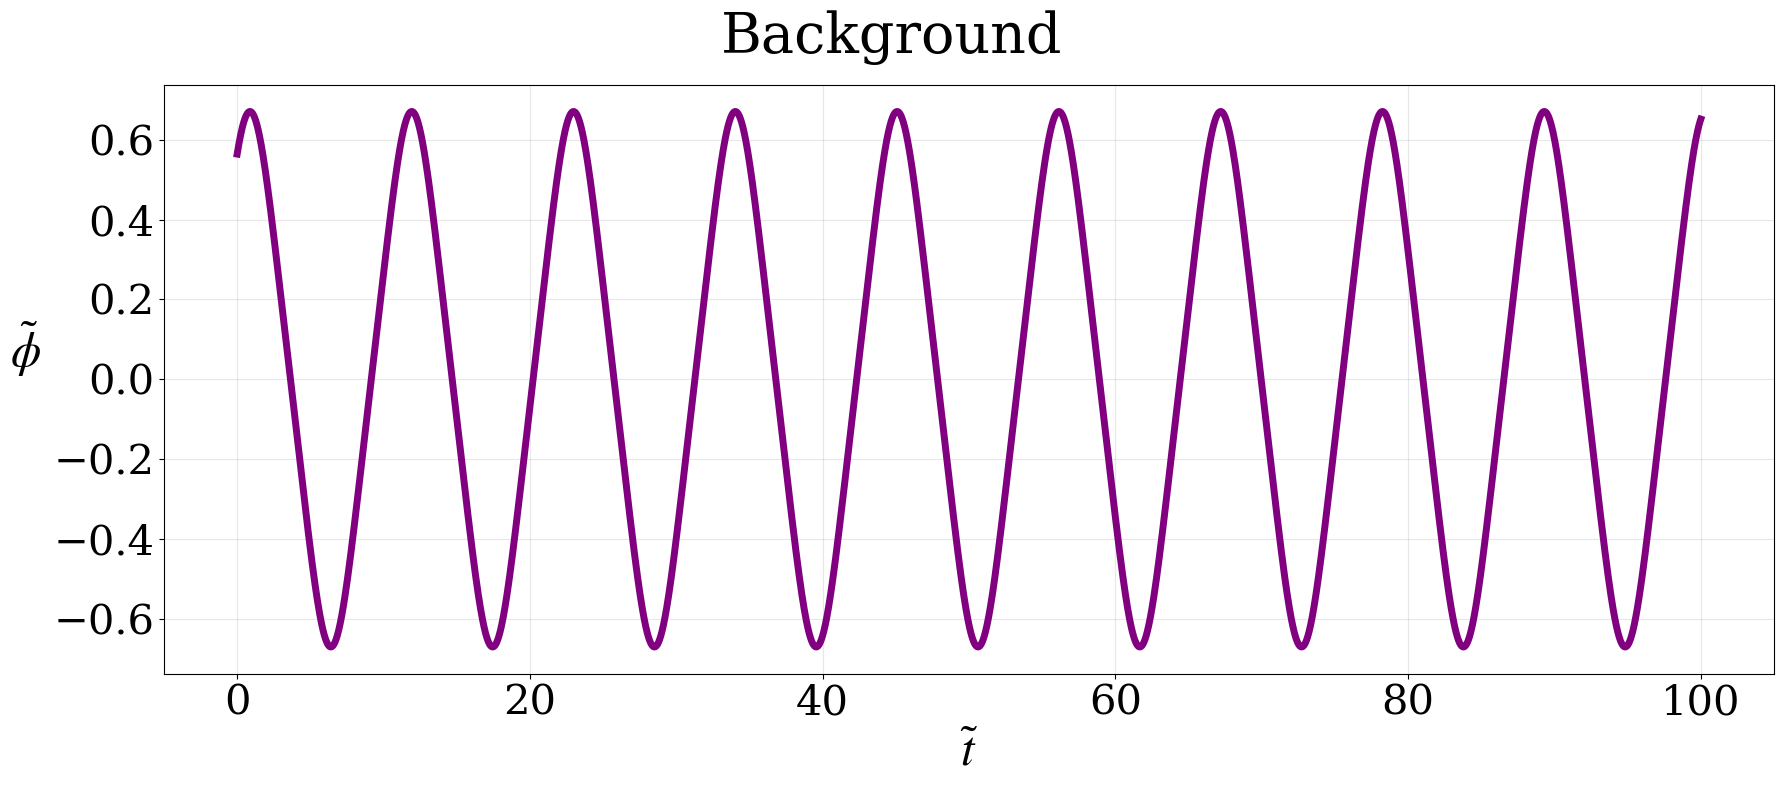

In [5]:
plt.figure(figsize = (18, 8))

plt.plot(sol.t, phi_sol, lw = 5, color = "purple")
plt.ylabel(r"$\tilde{\phi}$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.suptitle("Background", fontsize = 40)
plt.tight_layout()
plt.show()

### Perturbaciones

In [6]:
# Armemos un código para graficar las perturbaciones
def pert(t, y, k, g):
    phi, phi_dot, dphi_k, dphi_dot_k, chi_k, chi_dot_k = y
    
    # Ecuación para φ
    phi_ddot = - phi **3
    
    # Ecuaciones para δφ_k
    dphi_ddot_k = - (k**2 / 1 + 3 * phi**2) * dphi_k
    
    # Ecuaciones para χ_k
    chi_ddot_k = - (k**2 + g**2 * phi**2) * chi_k
    
    return [phi_dot, phi_ddot, dphi_dot_k, dphi_ddot_k, chi_dot_k, chi_ddot_k]

In [7]:
# Parámetros físicos
k = 1
g = 1e-2

# Rango de tiempo de integración
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, int(1e4))

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
# Perturbaciones
Omega_phi = k**2+ 3 * phi0**2
Omega_chi = k**2 + g**2 * phi0**2
dphi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
dphi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0]

In [8]:
# Resolvamos el sistema acoplado
sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

# Extraemos los resultados
dphi_sol = sol.y[2]
chi_sol = sol.y[4]

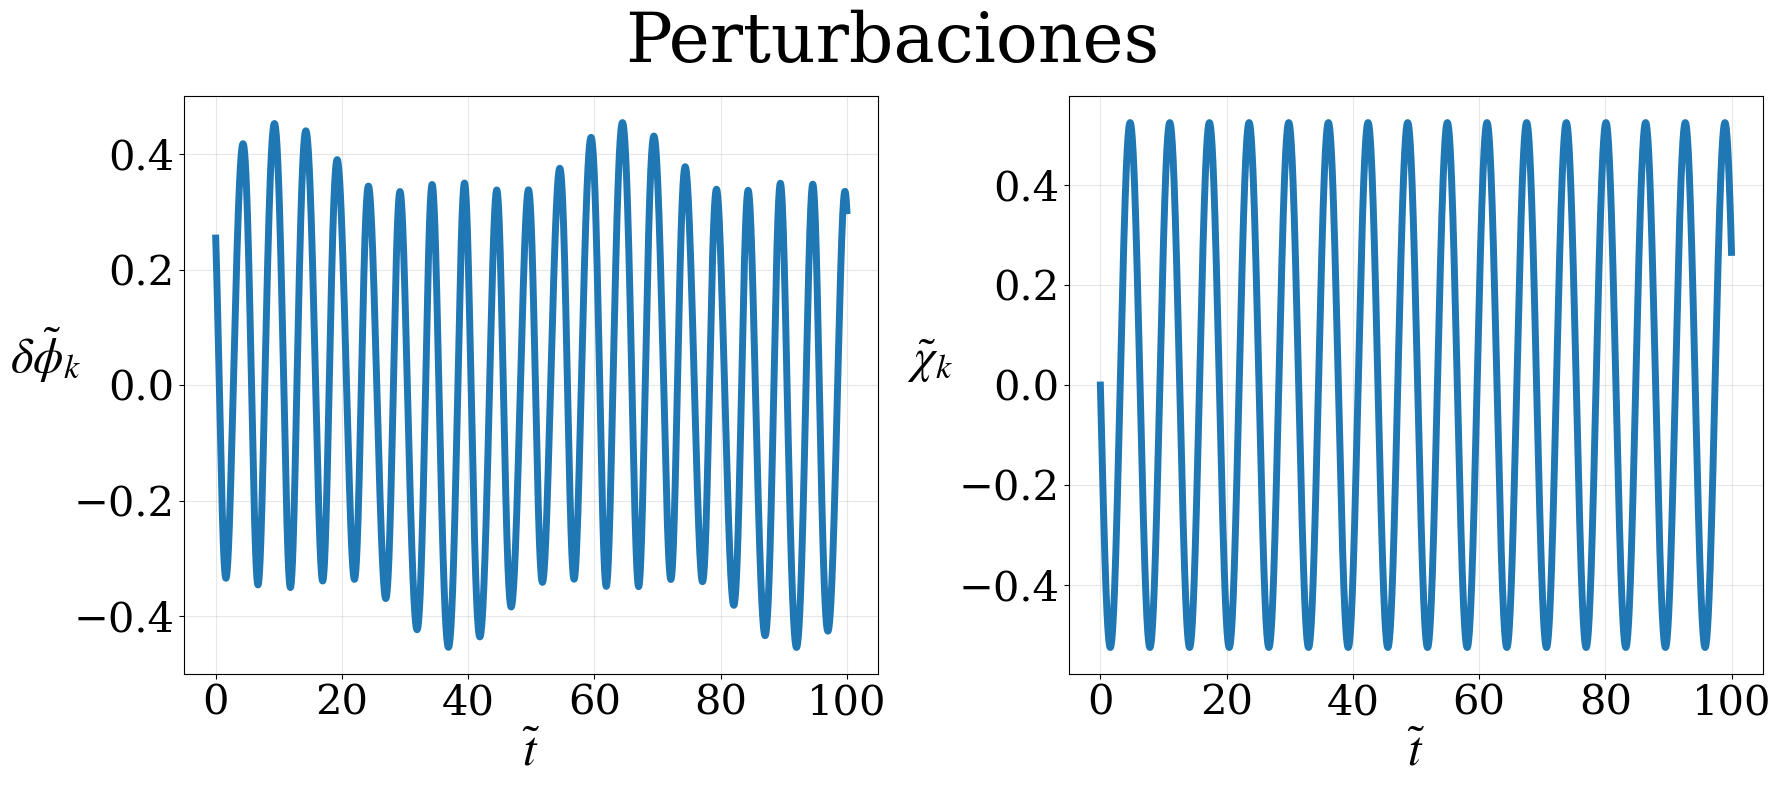

In [9]:
plt.figure(figsize = (18, 8))

plt.subplot(1,2,1)
plt.plot(sol.t, dphi_sol, lw = 5)
plt.ylabel(r"$\delta \tilde{\phi}_k$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.subplot(1,2,2)
plt.plot(sol.t, chi_sol, lw = 5)
plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.suptitle("Perturbaciones", fontsize = 50)
plt.tight_layout()
plt.show()

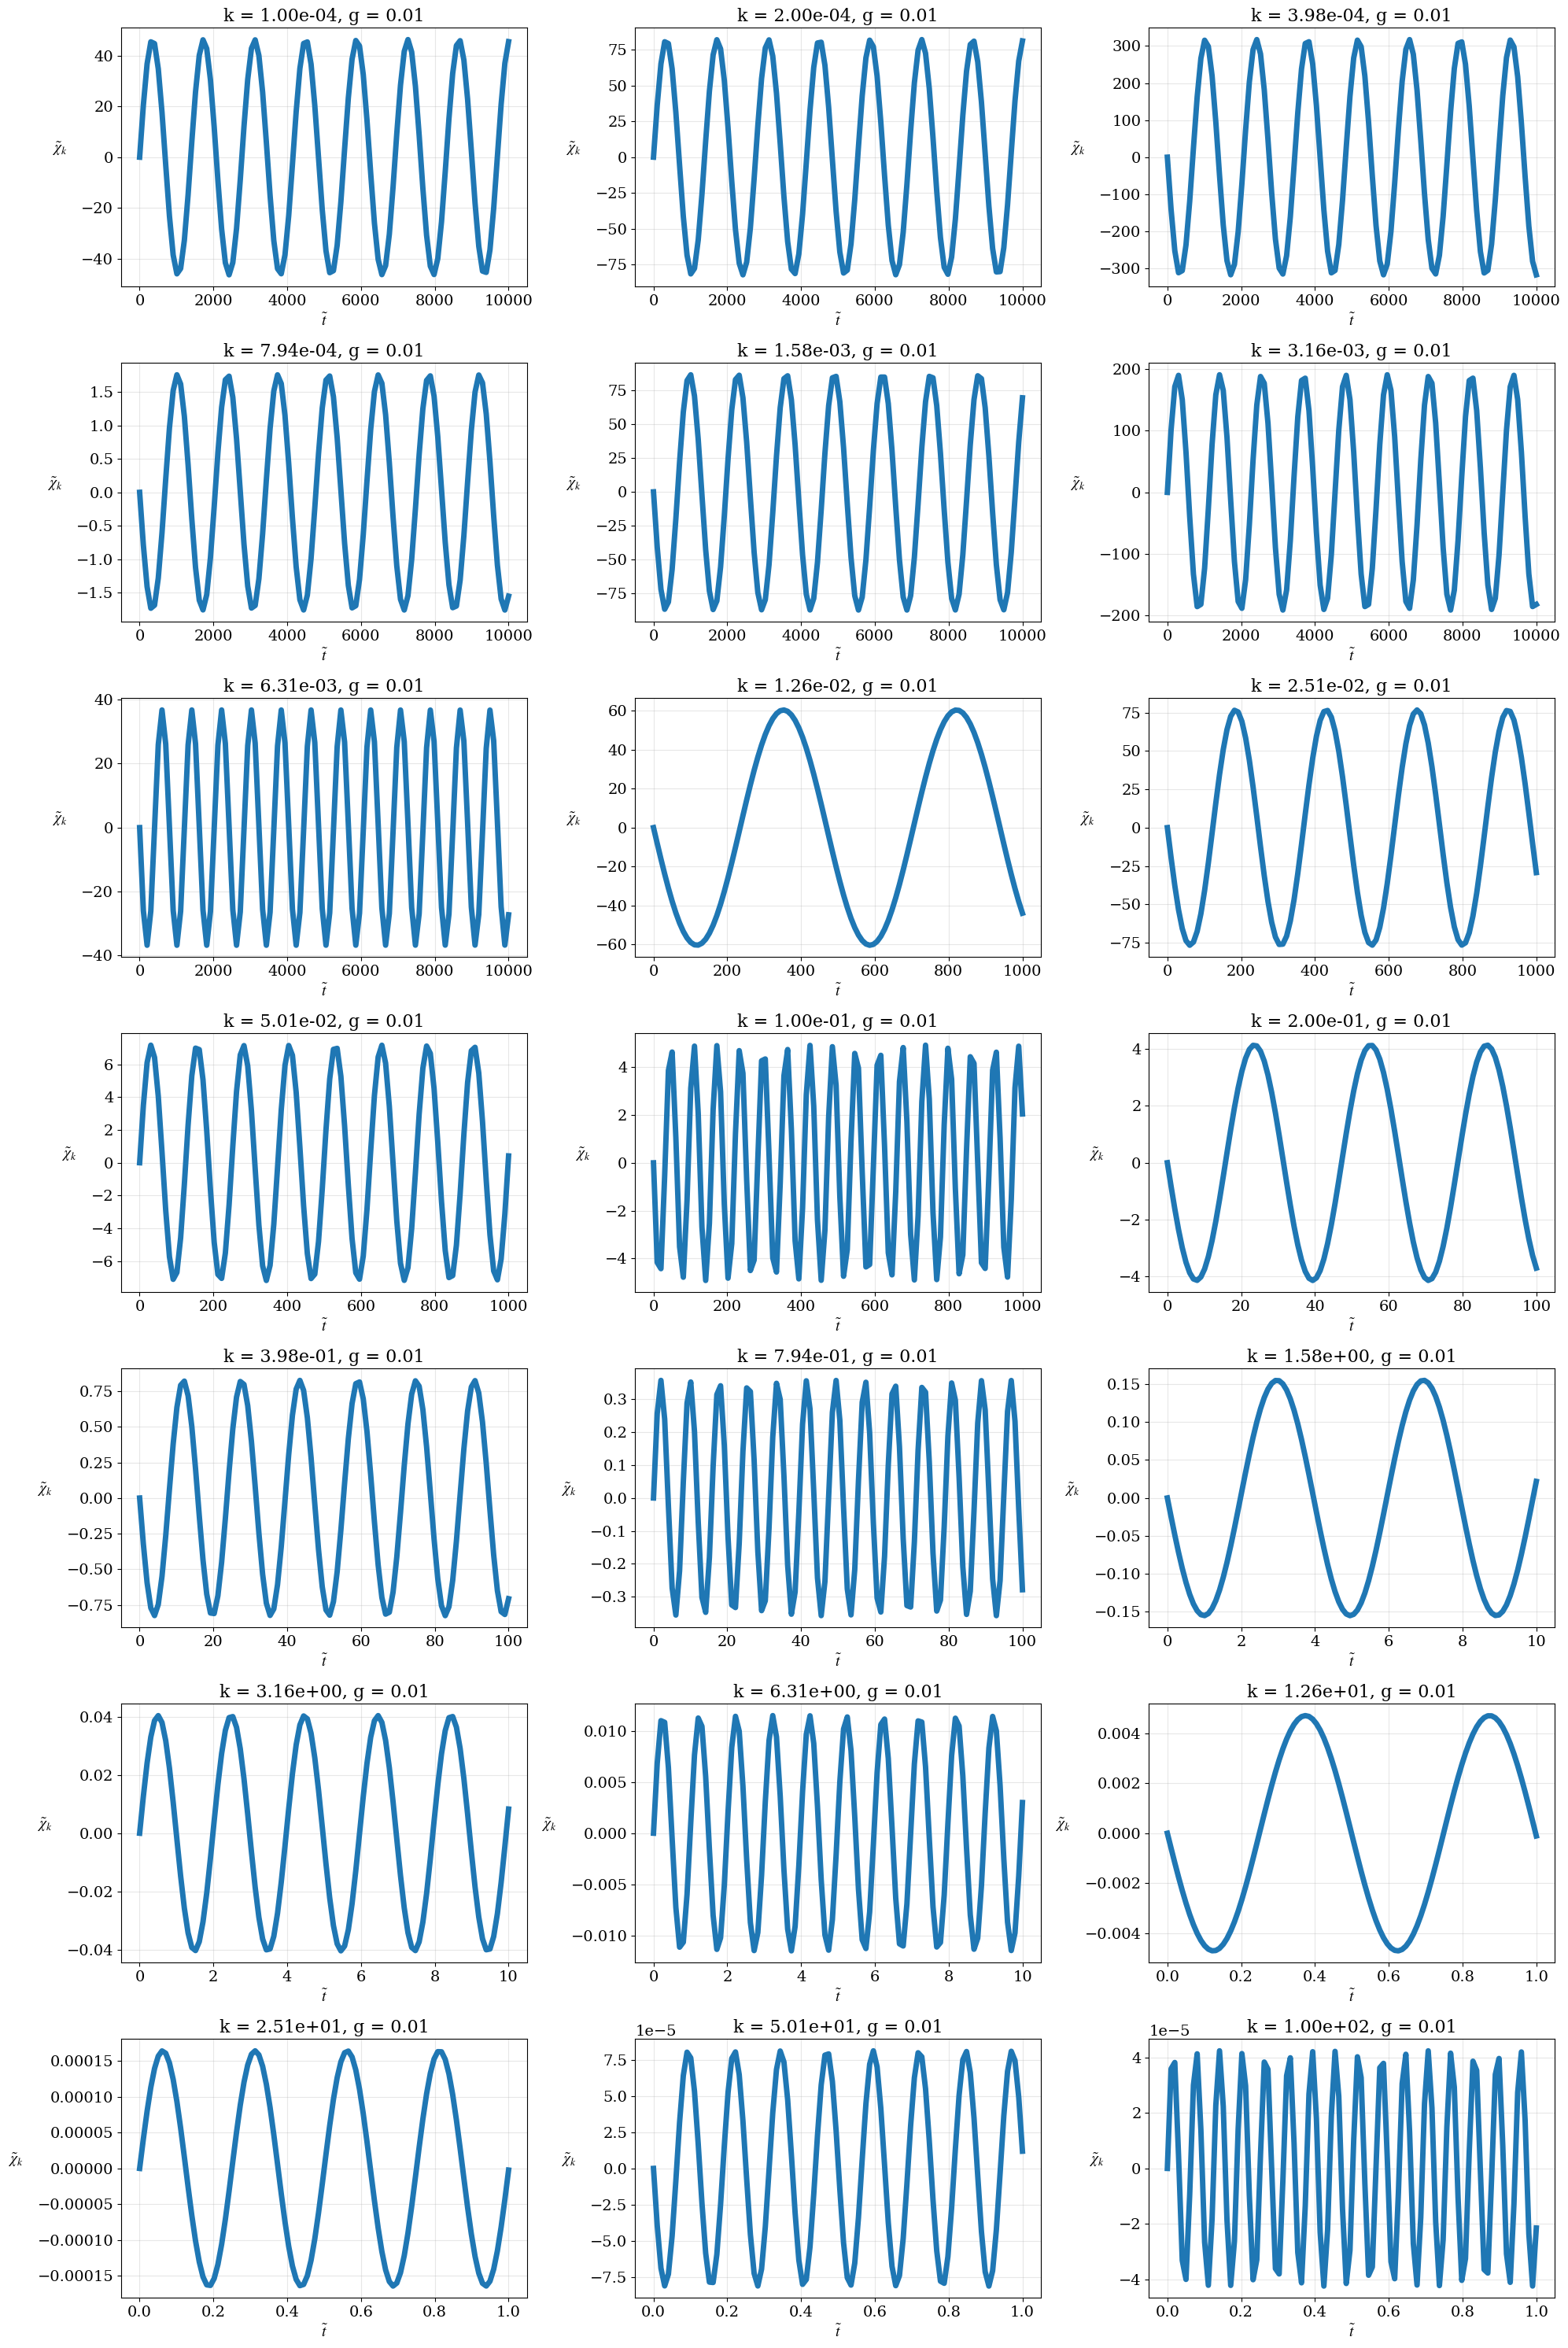

In [10]:
# Ahora veamos qué pasa para las amplitudes de chi de los modos para distintos valores de k

# Parámetros físicos
K = np.logspace(-4, 2, num=21)
g = 1e-2

# Rango de tiempo de integración
t0, tf = 0, [1e4,1e4,1e4,1e4,1e4,1e4,1e4,1e3,1e3,1e3,1e3,1e2,1e2,1e2,10,10,10,1,1,1,1]

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)

plt.figure(figsize = (20, 30))
i = 0

for k in K:
    t_eval = np.linspace(t0, tf[i], int(1e2))

    # Perturbaciones
    Omega_phi = k**2+ 3 * phi0**2
    Omega_chi = k**2 + g**2 * phi0**2
    dphi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0]

    # Resolvamos el sistema acoplado
    sol = solve_ivp(pert, [t0, tf[i]], y0, args=(k, g), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

    # Extraemos los resultados
    chi_sol = sol.y[4]
    i = i + 1

    plt.subplot(7,3,i)
    plt.plot(sol.t, chi_sol, lw = 5)
    plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal")
    plt.xlabel(r"$\tilde{t}$")
    plt.grid(alpha = 0.3)
    plt.title(f"k = {k:.2e}, g = {g}")

plt.tight_layout()
plt.show()

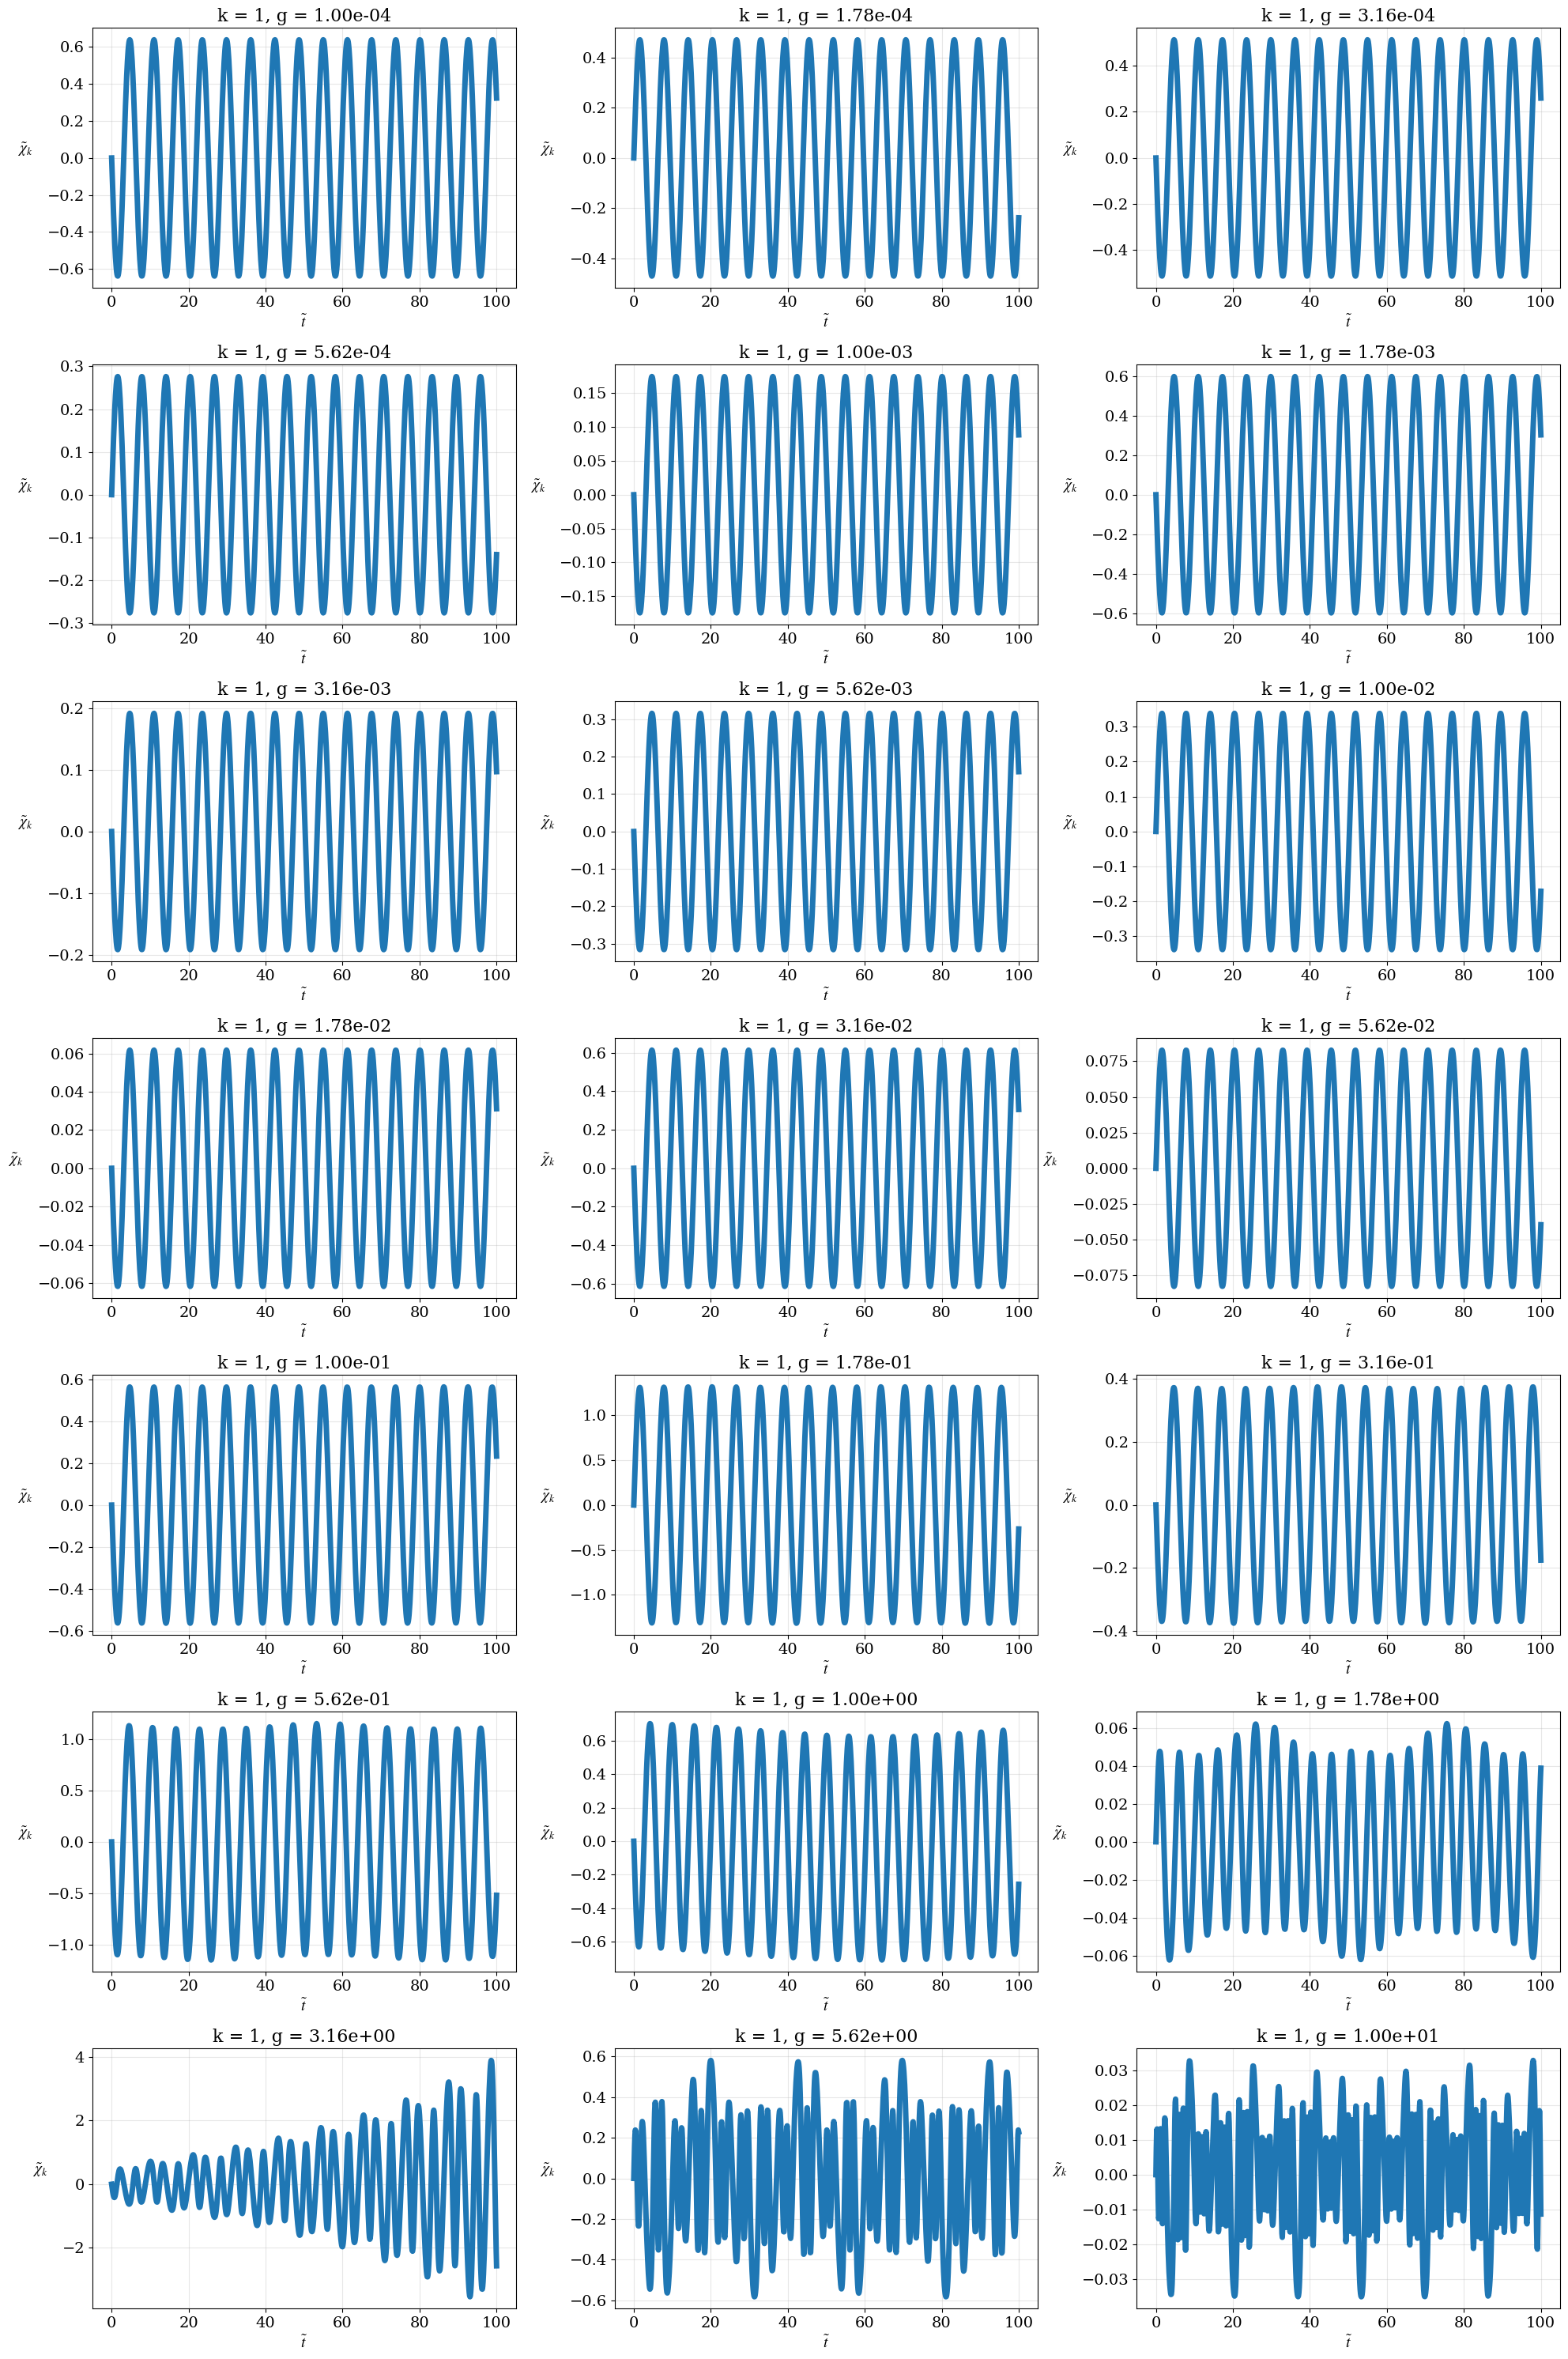

In [11]:
# Ahora veamos qué pasa para las amplitudes de chi de los modos para distintos valores de g

# Parámetros físicos
k = 1
G = np.logspace(-4,1,num=21)

# Rango de tiempo de integración
t0, tf = 0, 100

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)

plt.figure(figsize = (20, 30))
i = 0

for g in G:
    t_eval = np.linspace(t0, tf, int(1e3))

    # Perturbaciones
    Omega_phi = k**2+ 3 * phi0**2
    Omega_chi = k**2 + g**2 * phi0**2
    dphi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0]

    # Resolvamos el sistema acoplado
    sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method = "Radau", rtol=1e-8, atol=1e-8)

    # Extraemos los resultados
    chi_sol = sol.y[4]
    i = i + 1

    plt.subplot(7,3,i)
    plt.plot(sol.t, chi_sol, lw = 5)
    plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal")
    plt.xlabel(r"$\tilde{t}$")
    plt.grid(alpha = 0.3)
    plt.title(f"k = {k}, g = {g:.2e}")

plt.tight_layout()
plt.show()

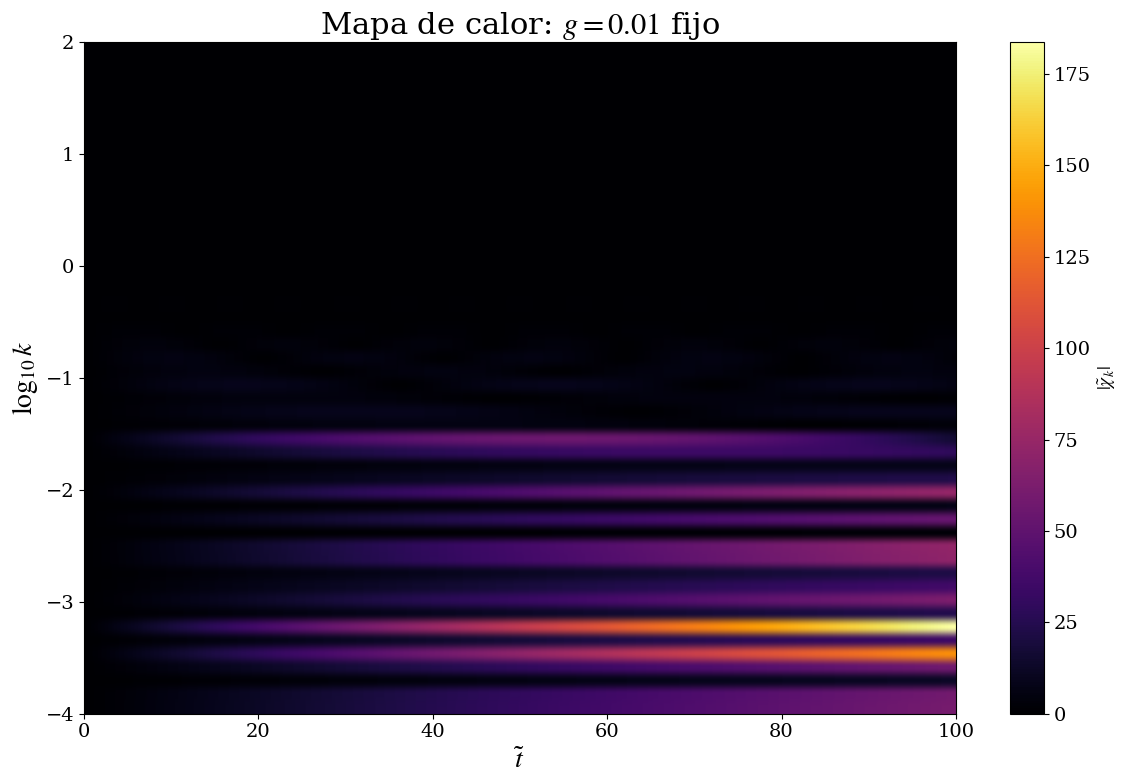

In [12]:
# Armemos tablas de instabilidad cómo las que armamos para la ecuación de Mathieu
# Parámetros
g = 1e-2  # g fijo
K = np.logspace(-4, 2, num=50)  # valores de k (eje y)
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, 500)  # eje x (tiempo)

# Condiciones iniciales background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)

# Prealoca matriz para amplitudes
chi_matrix = np.zeros((len(K), len(t_eval)))

for i, k in enumerate(K):
    Omega_phi = k**2 + 3 * phi0**2
    dphi_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0]
    sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method="RK45", rtol=1e-8, atol=1e-8)
    chi_matrix[i, :] = sol.y[4]  # amplitud de chi_k para cada t

# Graficar el mapa de calor
plt.figure(figsize=(12, 8))
extent = [t_eval[0], t_eval[-1], np.log10(K[0]), np.log10(K[-1])]
plt.imshow(np.abs(chi_matrix), aspect='auto', origin='lower', extent=extent, cmap='inferno')
plt.colorbar(label=r'$|\tilde{\chi}_k|$')
plt.xlabel(r'$\tilde{t}$', fontsize=20)
plt.ylabel(r'$\log_{10} k$', fontsize=20)
plt.title(f'Mapa de calor: $g={g}$ fijo', fontsize=22)
plt.tight_layout()
plt.show()

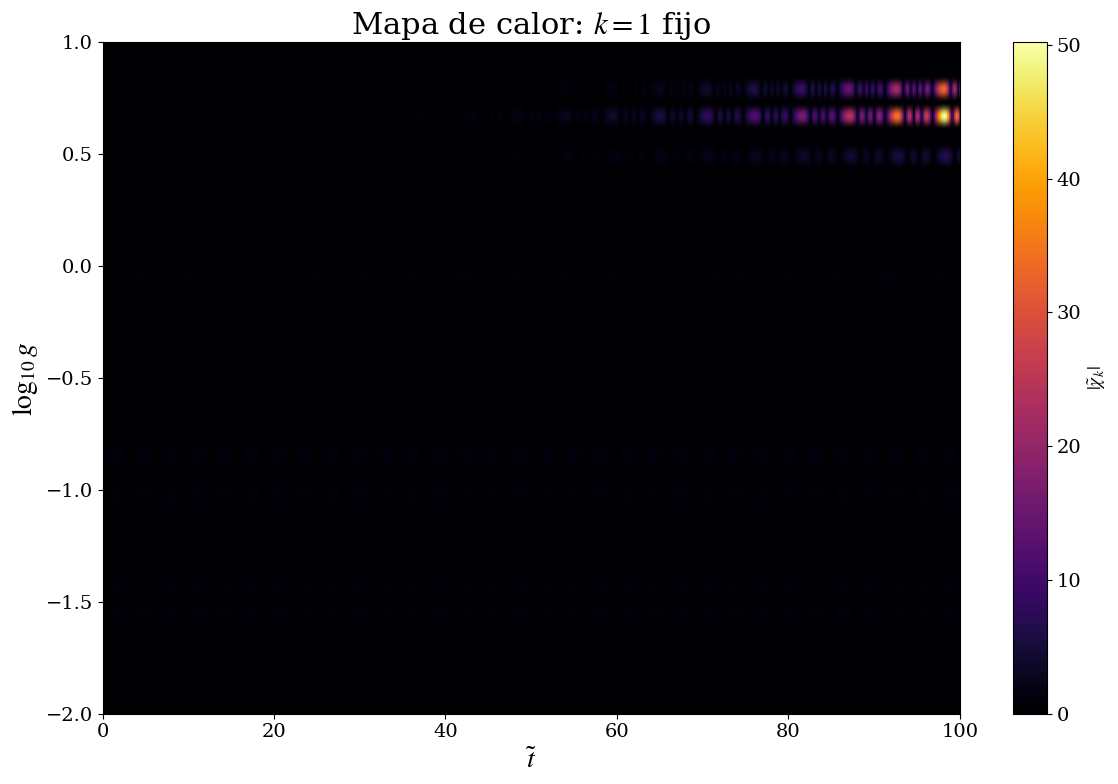

In [13]:
# Armemos tablas de instabilidad cómo las que armamos para la ecuación de Mathieu
# Parámetros
G = np.logspace(-2, 1, num=50)
k = 1  #Fijo
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, 500)  # eje x (tiempo)

# Condiciones iniciales background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)

# Prealoca matriz para amplitudes
chi_matrix = np.zeros((len(G), len(t_eval)))

for i, g in enumerate(G):
    Omega_phi = k**2 + 3 * phi0**2
    dphi_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0]
    sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method="RK45", rtol=1e-8, atol=1e-8)
    chi_matrix[i, :] = sol.y[4]  # amplitud de chi_k para cada t

# Graficar el mapa de calor
plt.figure(figsize=(12, 8))
extent = [t_eval[0], t_eval[-1], np.log10(G[0]), np.log10(G[-1])]
plt.imshow(np.abs(chi_matrix), aspect='auto', origin='lower', extent=extent, cmap='inferno')
plt.colorbar(label=r'$|\tilde{\chi}_k|$')
plt.xlabel(r'$\tilde{t}$', fontsize=20)
plt.ylabel(r'$\log_{10} g$', fontsize=20)
plt.title(f'Mapa de calor: $k={k}$ fijo', fontsize=22)
plt.tight_layout()
plt.show()

## Con expansión

### Background

In [14]:
# Armemos un código que resuelva el background
def background(t, y):
    phi, phi_dot, a, a_dot = y
    
    # Evolución de a(t)
    a_ddot = - a/3 * (phi_dot**2 - phi**4/4)
    H = a_dot/a
    
    # Ecuación para φ
    phi_ddot = -3 * H * phi_dot - phi **3

    return [phi_dot, phi_ddot, a_dot, a_ddot]

In [15]:
# Rango de tiempo de integración
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, int(1e4))

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

y0 = [phi0, phi_dot0, areh, areh_dot]

In [16]:
# Resolvamos el sistema acoplado
sol = solve_ivp(background, [t0, tf], y0, args=(), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

# Extraemos los resultados
phi_sol = sol.y[0]
a_sol = sol.y[2]

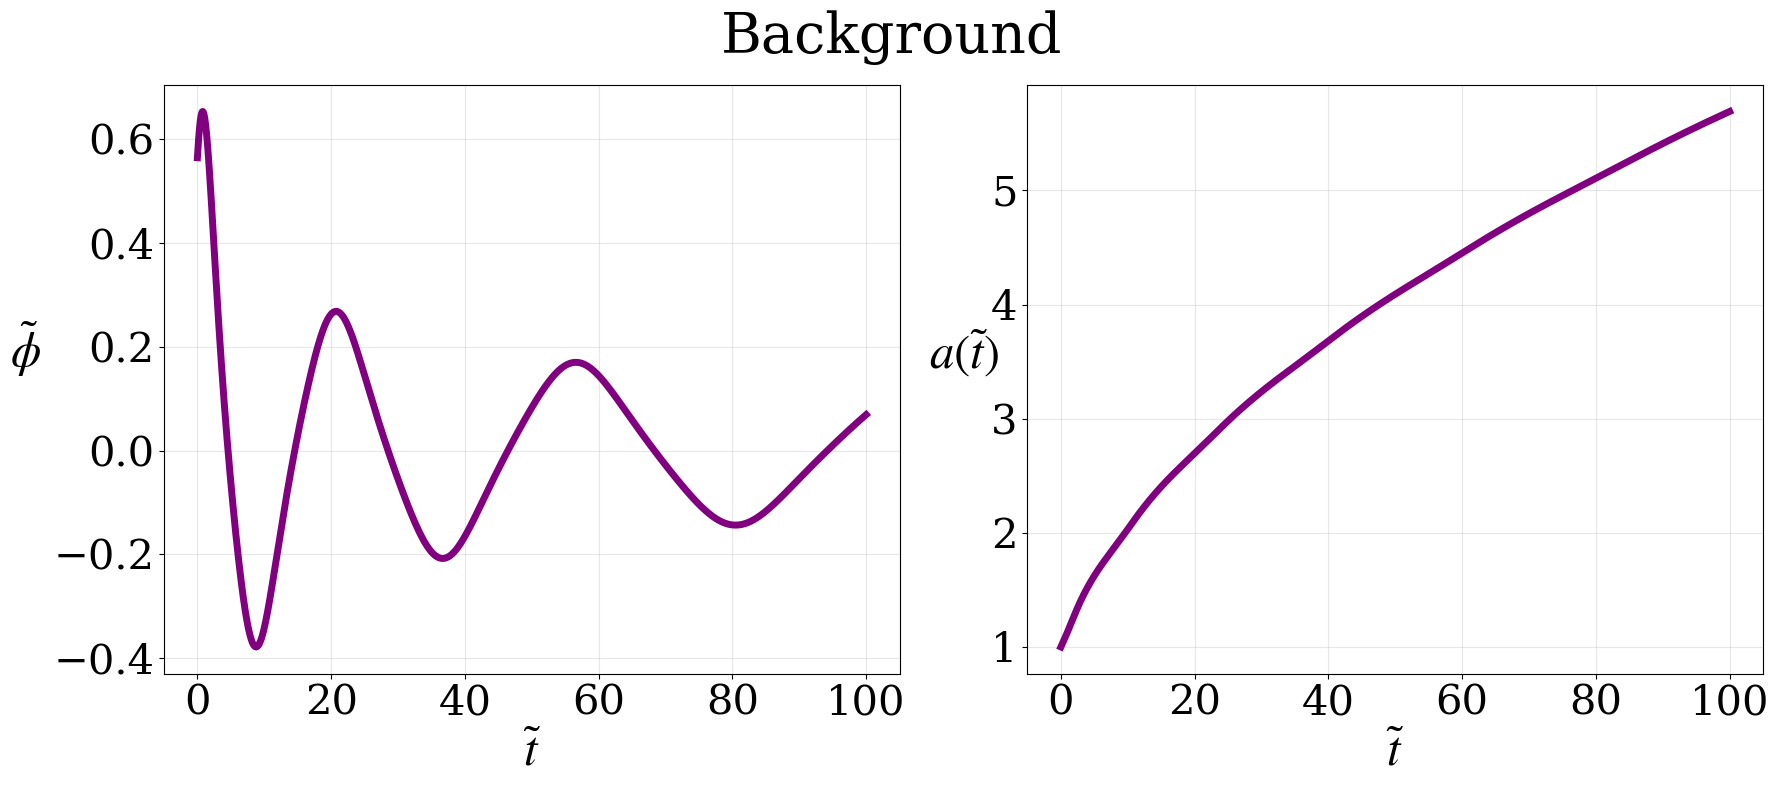

In [17]:
plt.figure(figsize = (18, 8))

plt.subplot(1,2,1)
plt.plot(sol.t, phi_sol, lw = 5, color = "purple")
plt.ylabel(r"$\tilde{\phi}$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.subplot(1,2,2)
plt.plot(sol.t, a_sol, lw = 5, color = "purple")
plt.ylabel(r"$a (\tilde{t})$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.suptitle("Background", fontsize = 40)
plt.tight_layout()
plt.show()

### Perturbaciones

In [18]:
# Armemos un código para graficar las perturbaciones
def pert(t, y, k, g):
    phi, phi_dot, dphi_k, dphi_dot_k, chi_k, chi_dot_k, a, a_dot = y

    # Evolución de a(t)
    a_ddot = - a/3 * (phi_dot**2 - phi**4/4)
    H = a_dot/a
    
    # Ecuación para φ
    phi_ddot = -3 * H * phi_dot - phi **3
    
    # Ecuaciones para δφ_k
    dphi_ddot_k = -3 * H * dphi_dot_k - (k**2 / a**2 + 3 * phi**2) * dphi_k
    
    # Ecuaciones para χ_k
    chi_ddot_k = -3 * H * chi_dot_k - (k**2 / a**2 + g**2 * phi**2) * chi_k
    
    return [phi_dot, phi_ddot, dphi_dot_k, dphi_ddot_k, chi_dot_k, chi_ddot_k, a_dot, a_ddot]

In [19]:
# Parámetros físicos
k = 1
g = 1e-2

# Rango de tiempo de integración
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, int(1e4))

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))
# Perturbaciones
Omega_phi = k**2/areh**2 + 3 * phi0**2
Omega_chi = k**2/areh**2 + g**2 * phi0**2
dphi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
dphi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0, areh, areh_dot]

In [20]:
# Resolvamos el sistema acoplado
sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

# Extraemos los resultados
dphi_sol = sol.y[2]
chi_sol = sol.y[4]

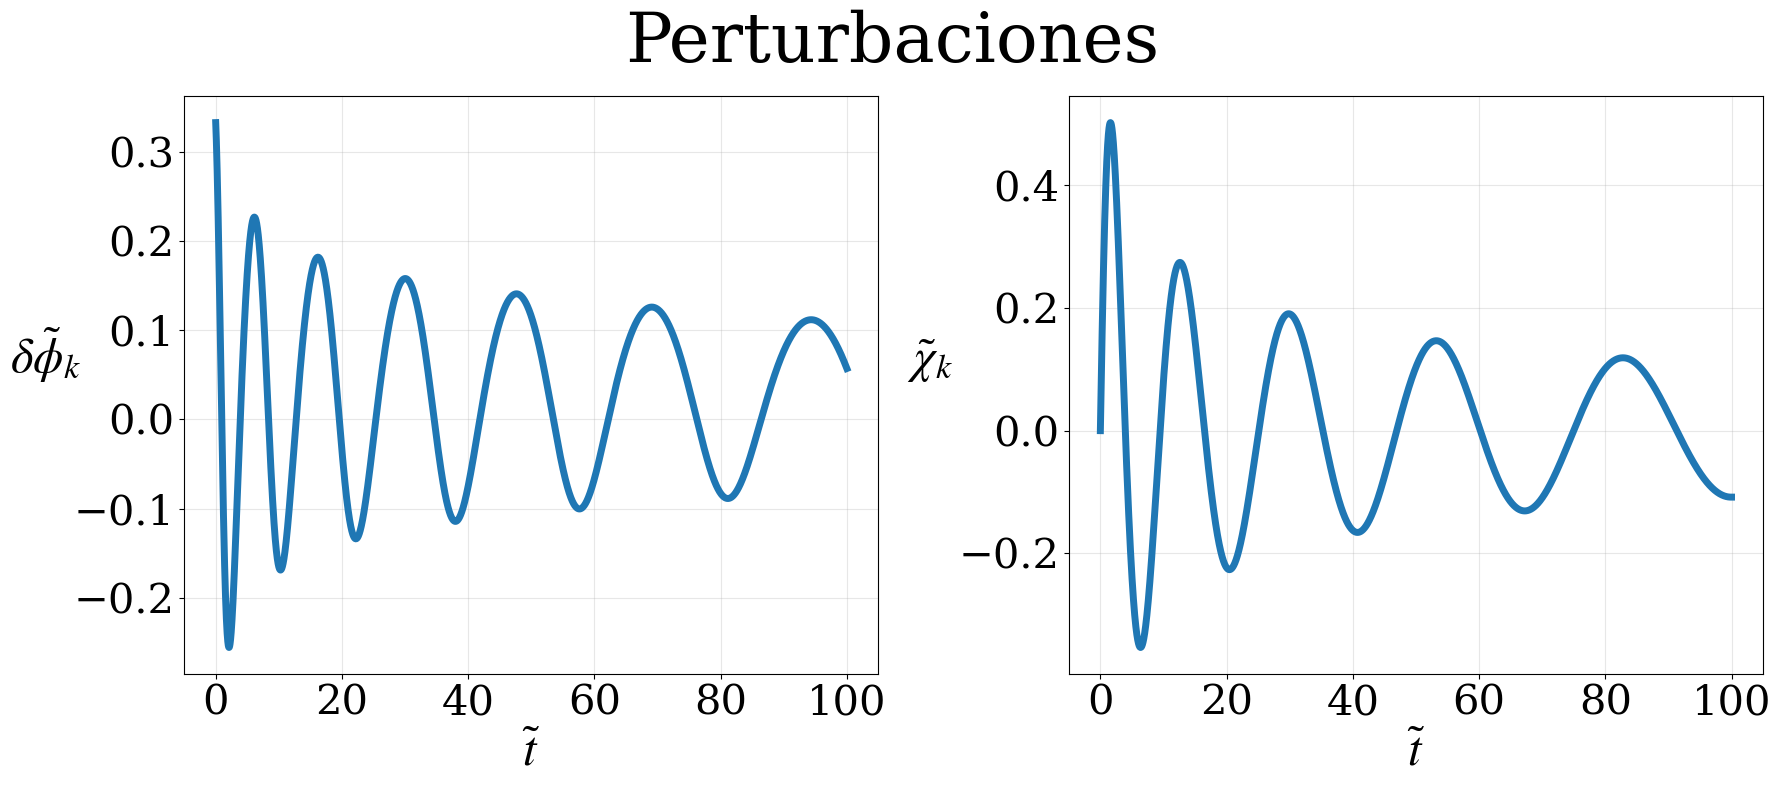

In [21]:
plt.figure(figsize = (18, 8))

plt.subplot(1,2,1)
plt.plot(sol.t, dphi_sol, lw = 5)
plt.ylabel(r"$\delta \tilde{\phi}_k$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.subplot(1,2,2)
plt.plot(sol.t, chi_sol, lw = 5)
plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.suptitle("Perturbaciones", fontsize = 50)
plt.tight_layout()
plt.show()

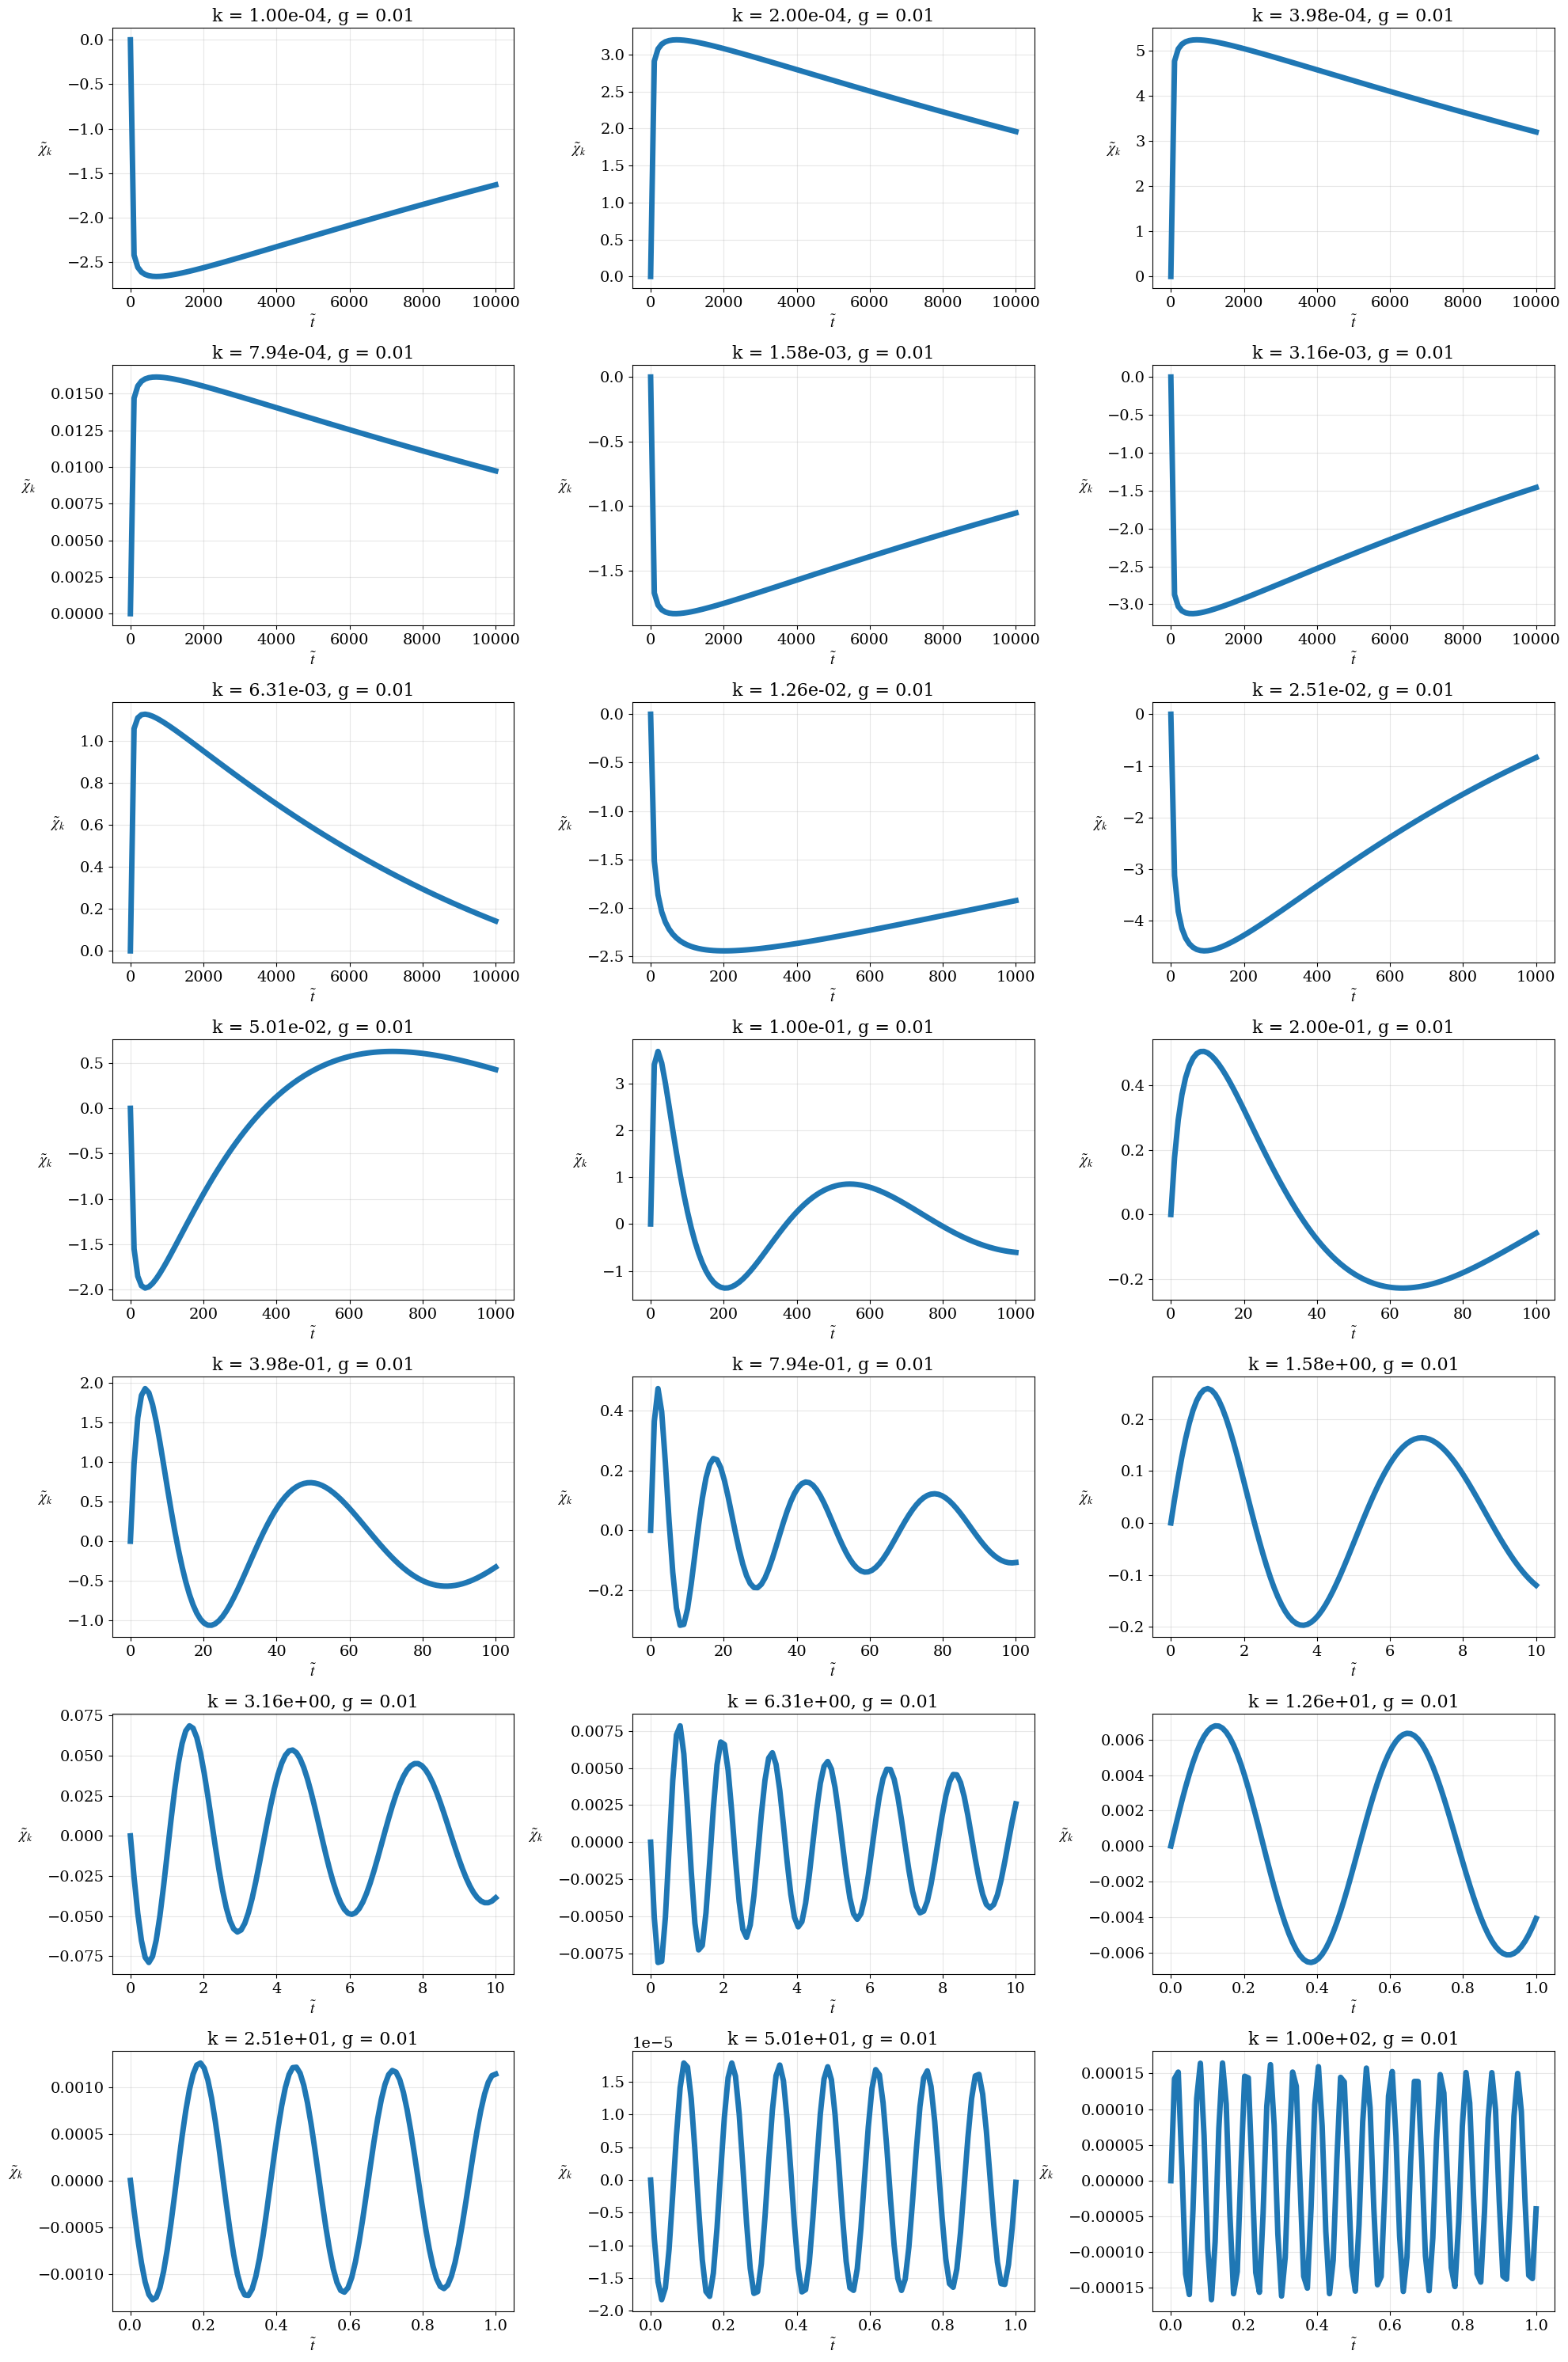

In [22]:
# Ahora veamos qué pasa para las amplitudes de chi de los modos para distintos valores de k

# Parámetros físicos
K = np.logspace(-4, 2, num=21)
g = 1e-2

# Rango de tiempo de integración
t0, tf = 0, [1e4,1e4,1e4,1e4,1e4,1e4,1e4,1e3,1e3,1e3,1e3,1e2,1e2,1e2,10,10,10,1,1,1,1]

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

plt.figure(figsize = (20, 30))
i = 0

for k in K:
    t_eval = np.linspace(t0, tf[i], int(1e2))

    # Perturbaciones
    Omega_phi = k**2+ 3 * phi0**2
    Omega_chi = k**2 + g**2 * phi0**2
    dphi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0, areh, areh_dot]

    # Resolvamos el sistema acoplado
    sol = solve_ivp(pert, [t0, tf[i]], y0, args=(k, g), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

    # Extraemos los resultados
    chi_sol = sol.y[4]
    i = i + 1

    plt.subplot(7,3,i)
    plt.plot(sol.t, chi_sol, lw = 5)
    plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal")
    plt.xlabel(r"$\tilde{t}$")
    plt.grid(alpha = 0.3)
    plt.title(f"k = {k:.2e}, g = {g}")

plt.tight_layout()
plt.show()

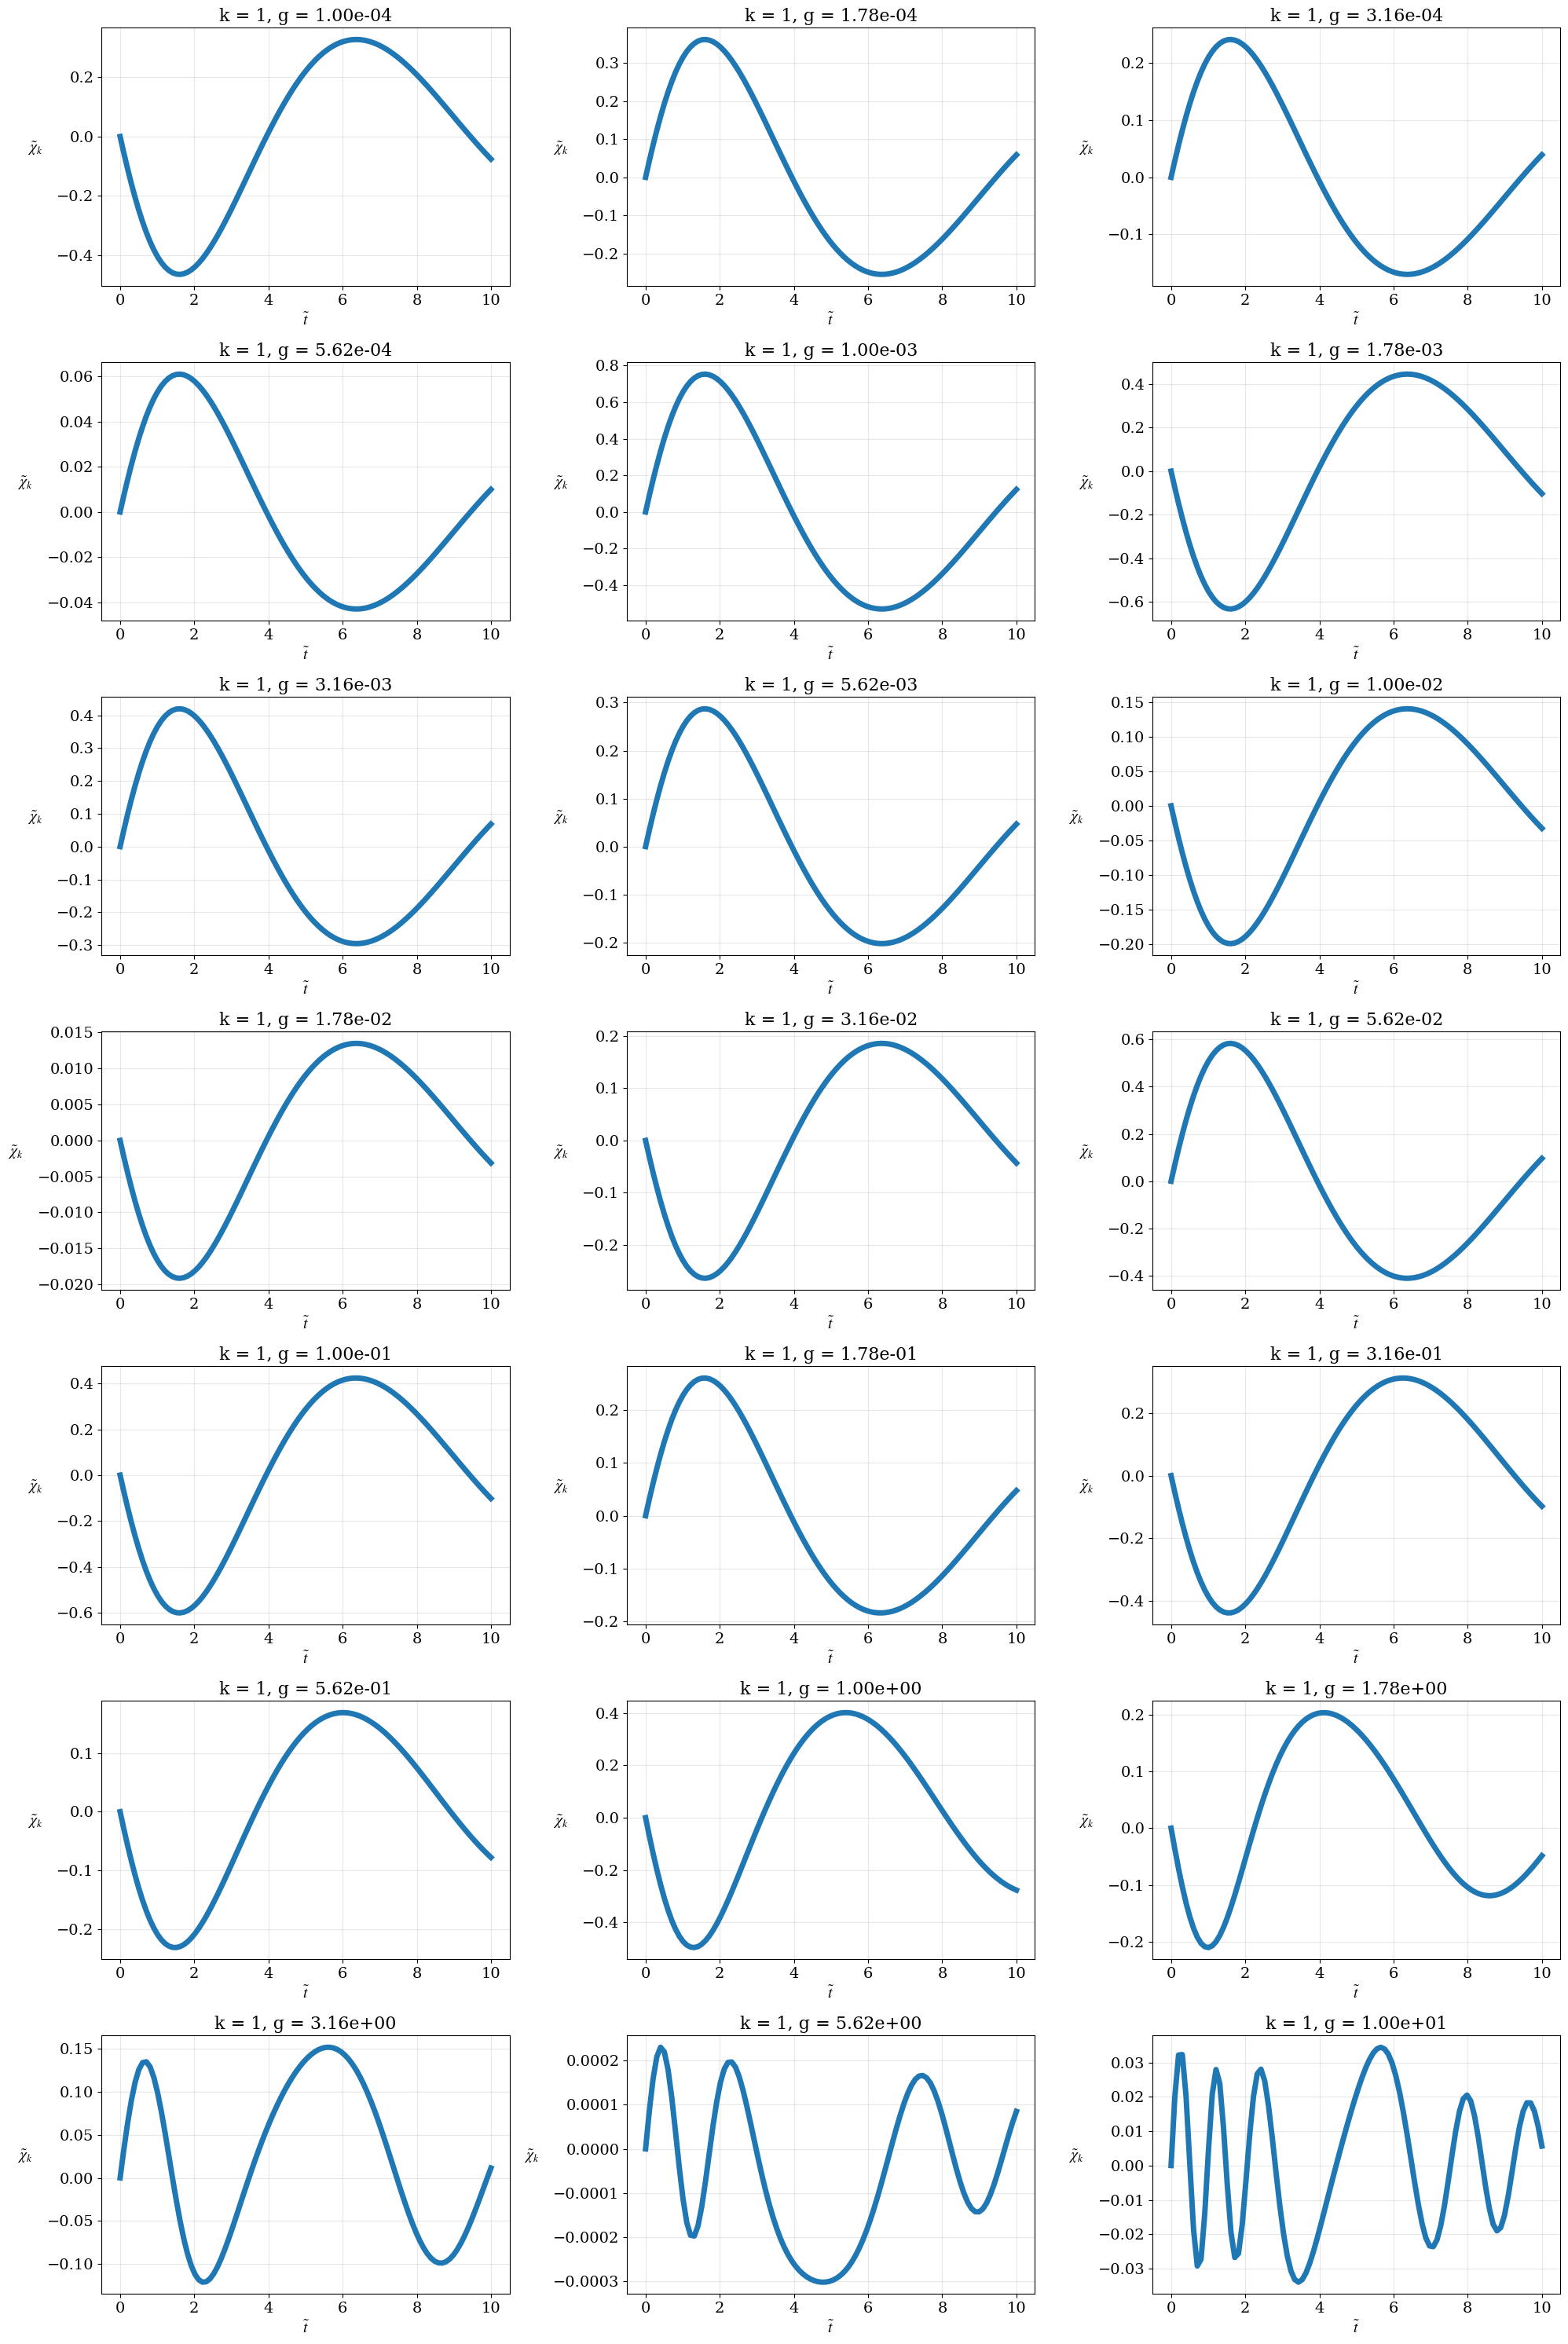

In [23]:
# Ahora veamos qué pasa para las amplitudes de chi de los modos para distintos valores de k

# Parámetros físicos
k = 1
G = np.logspace(-4,1,num=21)

# Rango de tiempo de integración
t0, tf = 0, 10
t_eval = np.linspace(t0, tf, int(1e2))


# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

plt.figure(figsize = (20, 30))
i = 0

for g in G:
    # Perturbaciones
    Omega_phi = k**2+ 3 * phi0**2
    Omega_chi = k**2 + g**2 * phi0**2
    dphi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0, areh, areh_dot]

    # Resolvamos el sistema acoplado
    sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

    # Extraemos los resultados
    chi_sol = sol.y[4]
    i = i + 1

    plt.subplot(7,3,i)
    plt.plot(sol.t, chi_sol, lw = 5)
    plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal")
    plt.xlabel(r"$\tilde{t}$")
    plt.grid(alpha = 0.3)
    plt.title(f"k = {k}, g = {g:.2e}")

plt.tight_layout()
plt.show()

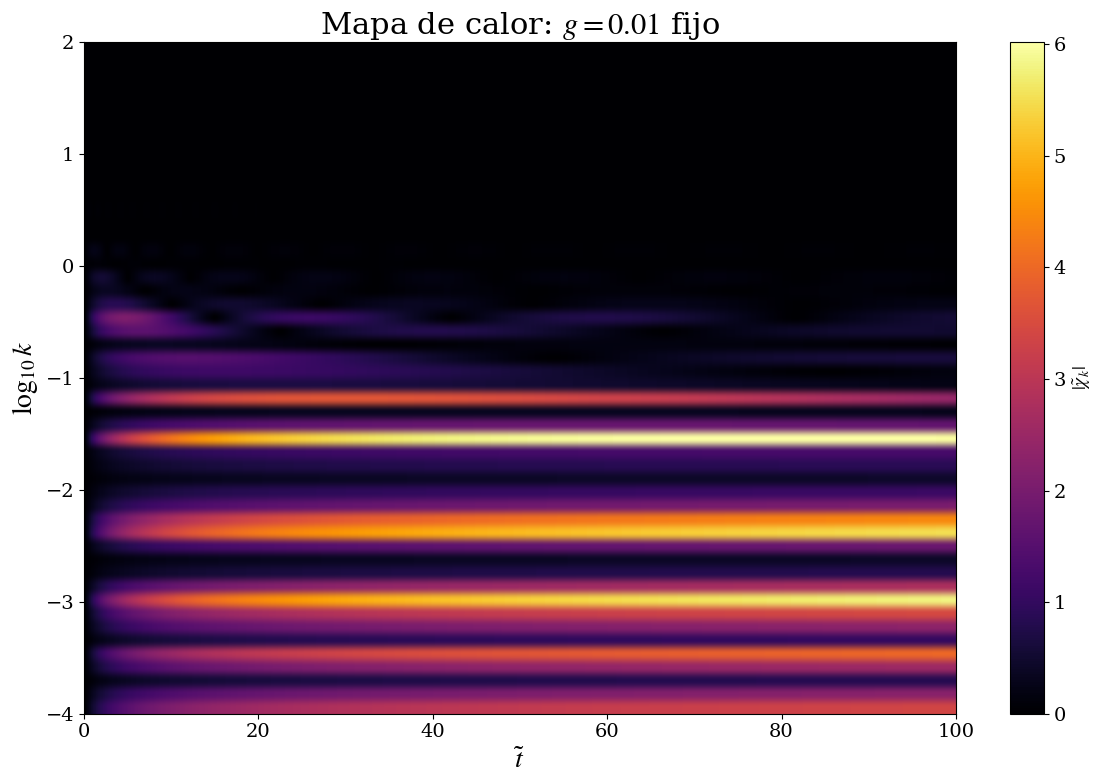

In [24]:
# Armemos tablas de instabilidad cómo las que armamos para la ecuación de Mathieu
# Parámetros
g = 1e-2  # g fijo
K = np.logspace(-4, 2, num=50)  # valores de k (eje y)
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, 500)  # eje x (tiempo)

# Condiciones iniciales background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

# Prealoca matriz para amplitudes
chi_matrix = np.zeros((len(K), len(t_eval)))

for i, k in enumerate(K):
    Omega_phi = k**2 + 3 * phi0**2
    dphi_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0, areh, areh_dot]
    sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method="RK45", rtol=1e-8, atol=1e-8)
    chi_matrix[i, :] = sol.y[4]  # amplitud de chi_k para cada t

# Graficar el mapa de calor
plt.figure(figsize=(12, 8))
extent = [t_eval[0], t_eval[-1], np.log10(K[0]), np.log10(K[-1])]
plt.imshow(np.abs(chi_matrix), aspect='auto', origin='lower', extent=extent, cmap='inferno')
plt.colorbar(label=r'$|\tilde{\chi}_k|$')
plt.xlabel(r'$\tilde{t}$', fontsize=20)
plt.ylabel(r'$\log_{10} k$', fontsize=20)
plt.title(f'Mapa de calor: $g={g}$ fijo', fontsize=22)
plt.tight_layout()
plt.show()

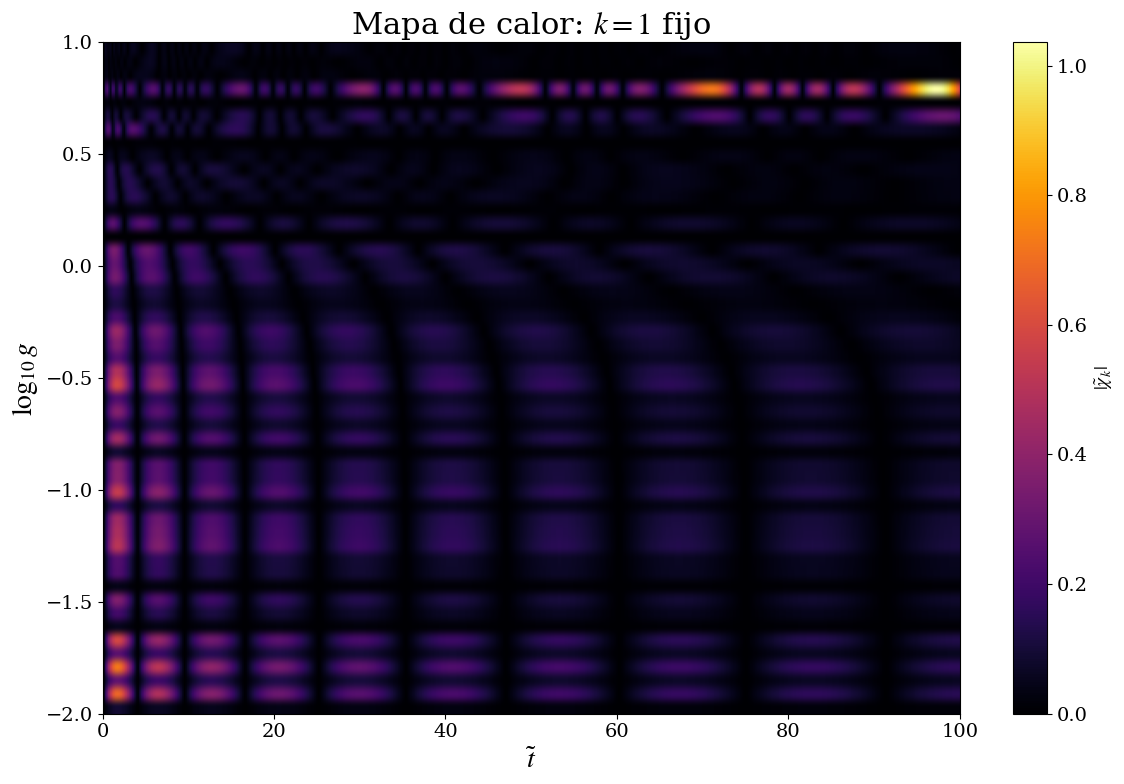

In [25]:
# Armemos tablas de instabilidad cómo las que armamos para la ecuación de Mathieu
# Parámetros
G = np.logspace(-2, 1, num=50)
k = 1  #Fijo
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, 500)  # eje x (tiempo)

# Condiciones iniciales background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

# Prealoca matriz para amplitudes
chi_matrix = np.zeros((len(G), len(t_eval)))

for i, g in enumerate(G):
    Omega_phi = k**2 + 3 * phi0**2
    dphi_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0, areh, areh_dot]
    sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method="RK45", rtol=1e-8, atol=1e-8)
    chi_matrix[i, :] = sol.y[4]  # amplitud de chi_k para cada t

# Graficar el mapa de calor
plt.figure(figsize=(12, 8))
extent = [t_eval[0], t_eval[-1], np.log10(G[0]), np.log10(G[-1])]
plt.imshow(np.abs(chi_matrix), aspect='auto', origin='lower', extent=extent, cmap='inferno')
plt.colorbar(label=r'$|\tilde{\chi}_k|$')
plt.xlabel(r'$\tilde{t}$', fontsize=20)
plt.ylabel(r'$\log_{10} g$', fontsize=20)
plt.title(f'Mapa de calor: $k={k}$ fijo', fontsize=22)
plt.tight_layout()
plt.show()

# Dinámica 2

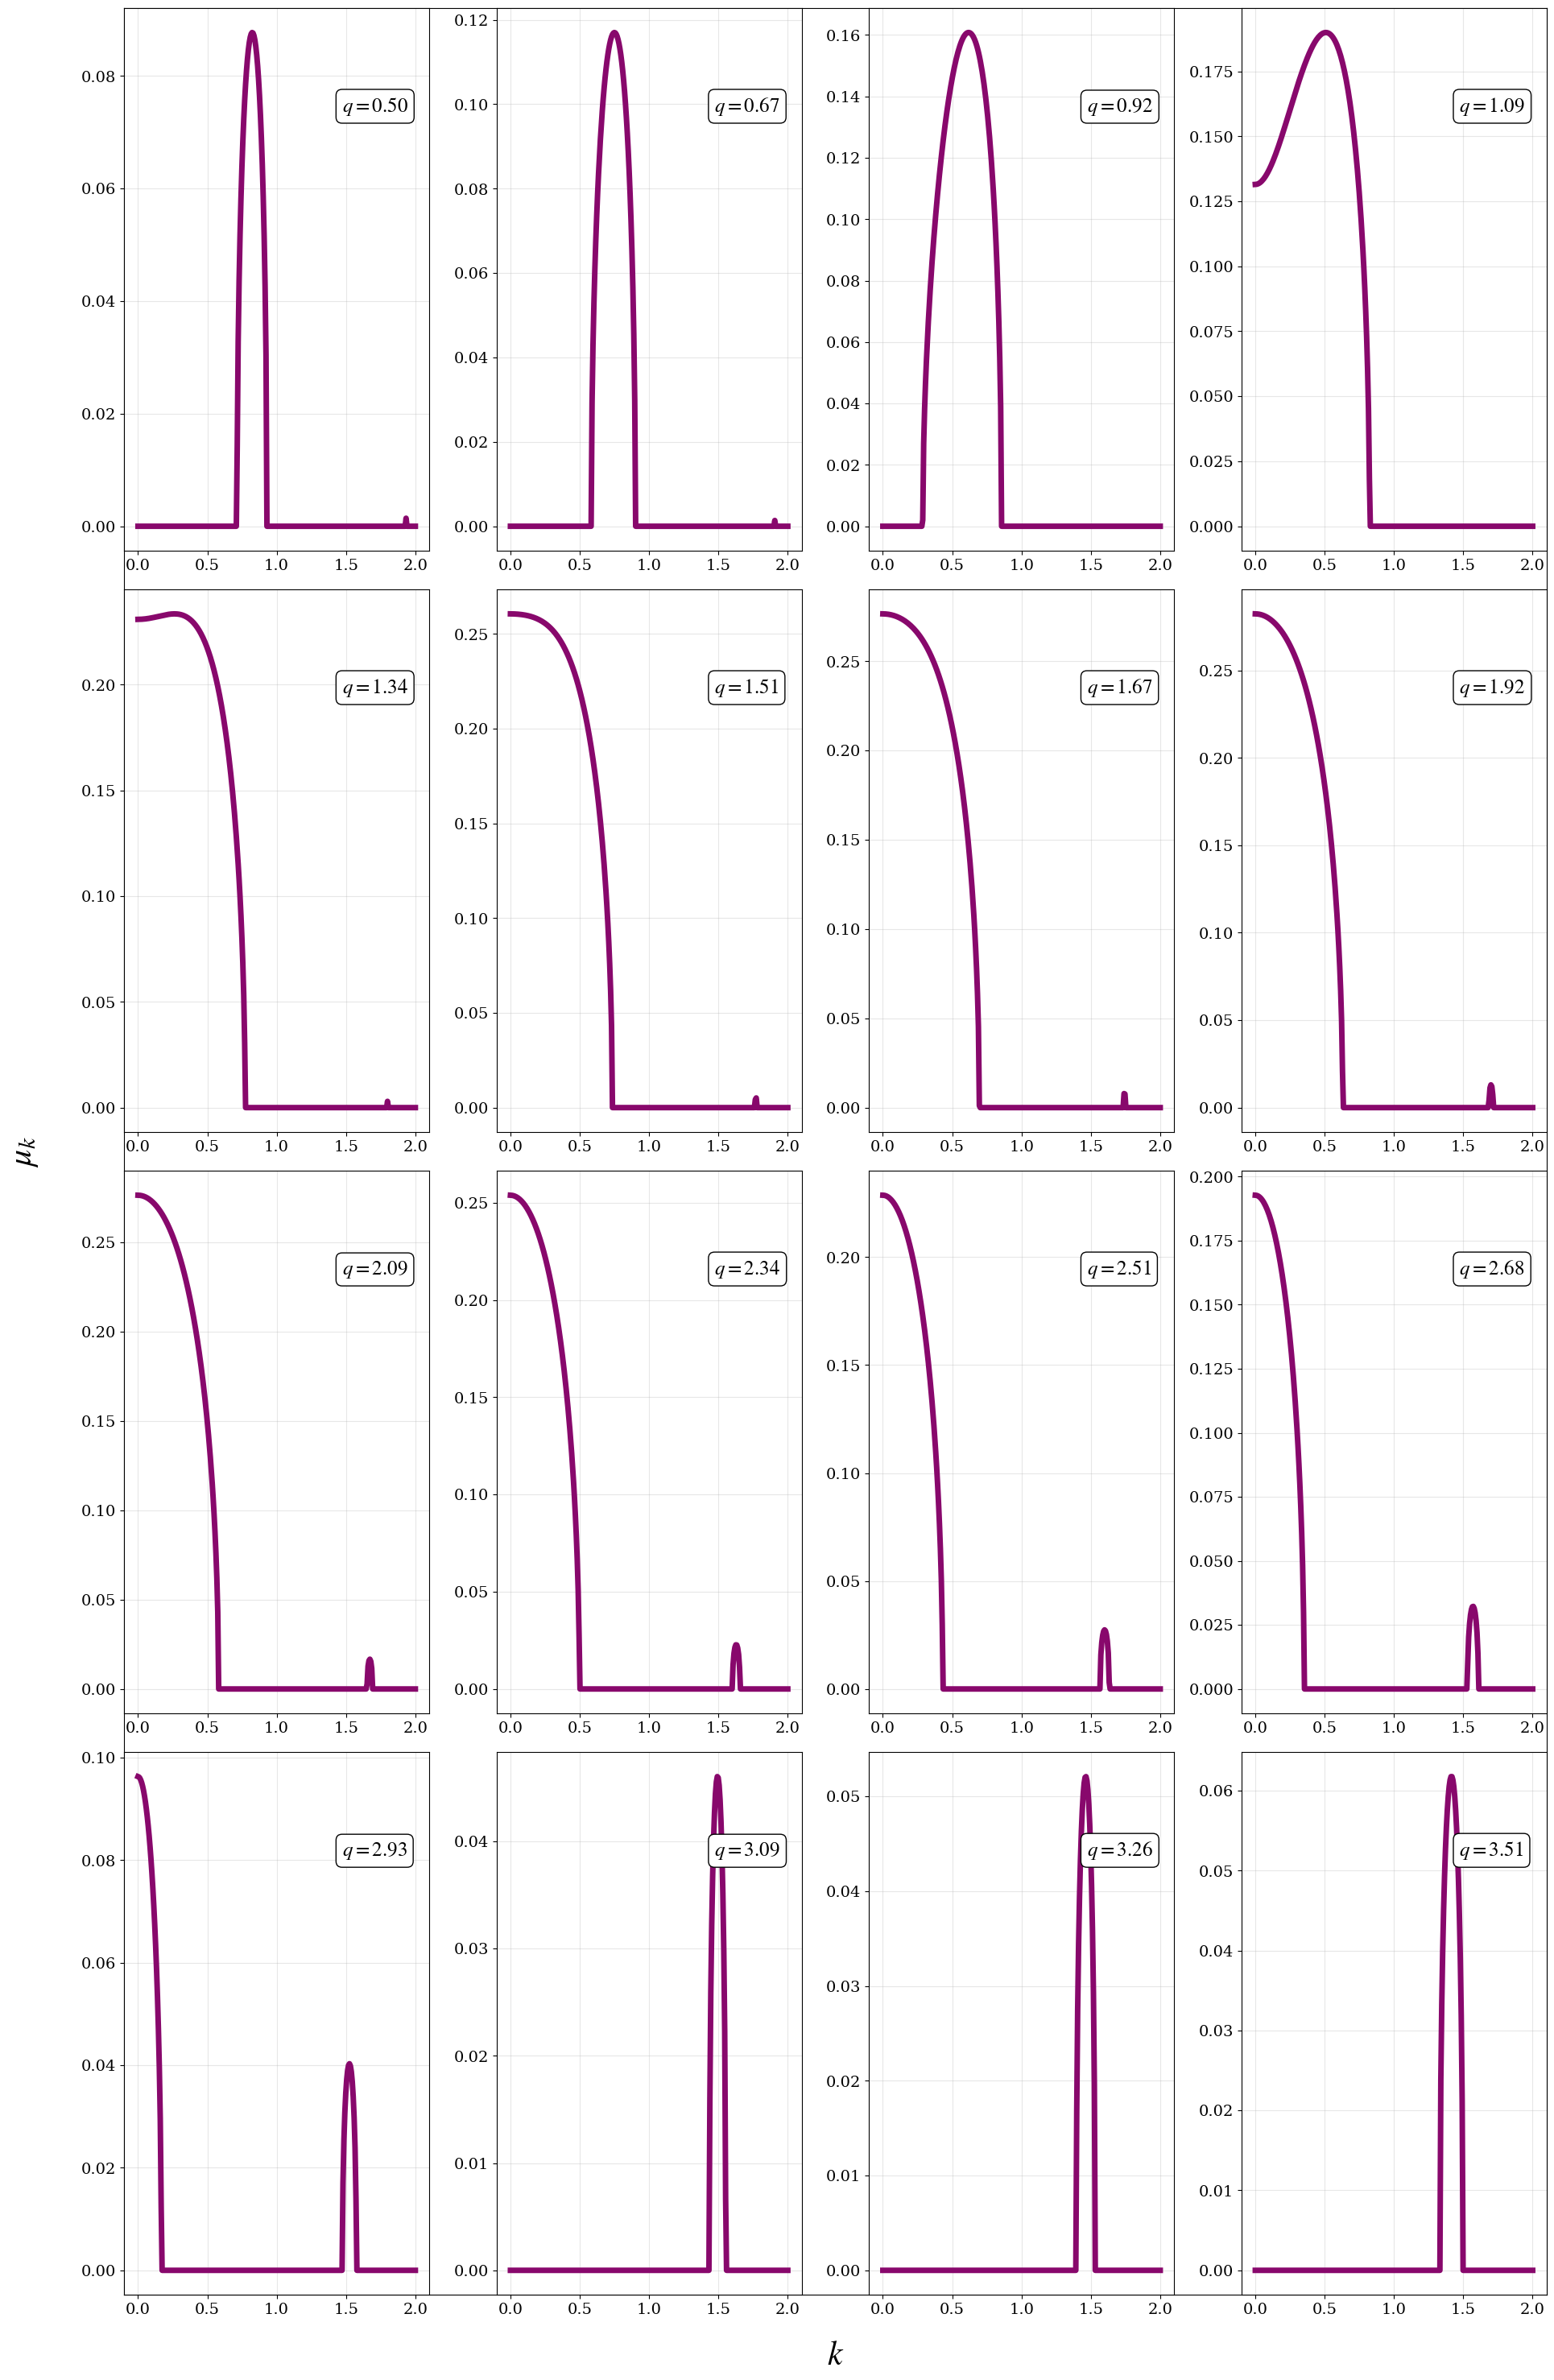

In [3]:
# Diagrama del coeficientente de Floquet en base a k para un g fijo
filename = "../Floquet/mathieu_lphi4(2).csv"

data = np.loadtxt(filename, delimiter=",")
qs = data[0, 1:]
ks = data[1:, 0]
mu = data[1:, 1:]

Q = np.linspace(0.5, 3.5, 16)
i = 0

plt.figure(figsize=(20, 30))
plt.xlabel(r'$k$', fontsize=30, labelpad=40)
plt.ylabel(r'$\mu_k$', fontsize=30, labelpad=75)
plt.xticks([])
plt.yticks([])

for q in Q:
    i += 1
    index = (np.abs(qs - q)).argmin()

    plt.subplot(4, 4, i)
    plt.plot(ks, np.real(mu[:, index]), label=f'$q={q}$', lw = 5, color = "#88086c")
    ymin, ymax = plt.gca().get_ylim()
    plt.text(x=ks[-80], y=ymax*0.8, s=rf'$q = {qs[index]:.2f}$', fontsize=18, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
    plt.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

In [6]:
# Función para las perturbaciones en el modelo λφ^4
def perturbation_lphi4(t, y, k, q):
    phi, phi_dot, chi_k, chi_dot_k = y
    phi_ddot = - phi**3
    chi_ddot_k = - (k**2 + q * phi**2) * chi_k
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

# Función para calcular el período de oscilación del inflatón
def oscilation_lphi4(E):
    def integrand(phi):
        V = 0.25 * phi**4
        return 1.0 / np.sqrt(2 * (E - V))
    phimax = (4*E)**(1/4)
    integral, _ = quad(integrand, 0, phimax)
    Tosc = 4*integral
    return Tosc

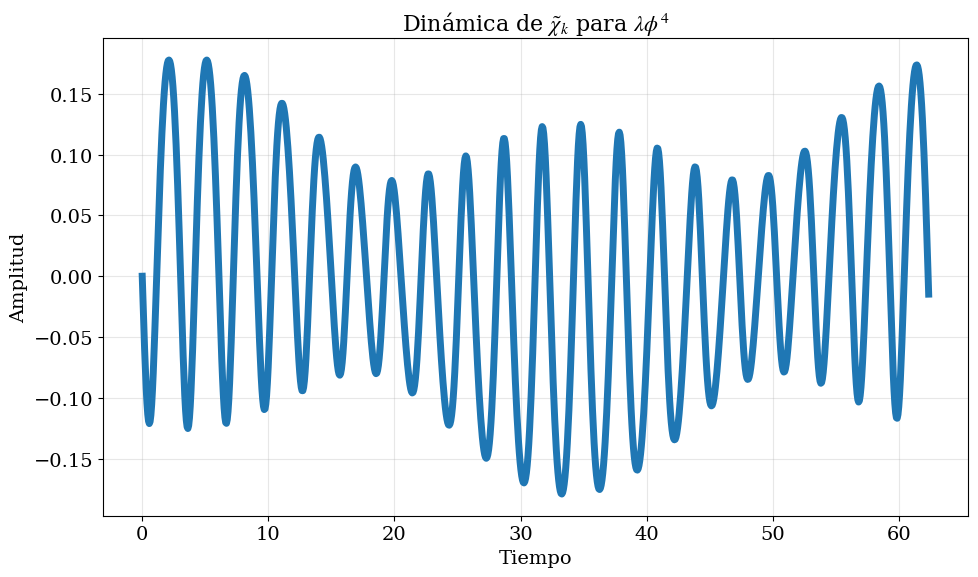

In [58]:
# Resolvamos la dinámica completa para un caso particular
q = 4
k = 1.5

# Condiciones iniciales
# Background
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)
# Perturbaciones
Omega_chi = k**2 + q**2 * phi0**2
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]

Tosc = oscilation_lphi4(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)
sol = solve_ivp(perturbation_lphi4, t_span, y0, t_eval=np.linspace(0, 10 * Tosc, 1000), method='RK45', rtol=1e-6, args=(k, q))


plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[2], label=r'$\chi_k(t)$', lw = 5)
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.title(r'Dinámica de $\tilde{\chi}_k$ para $\lambda \phi^4$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

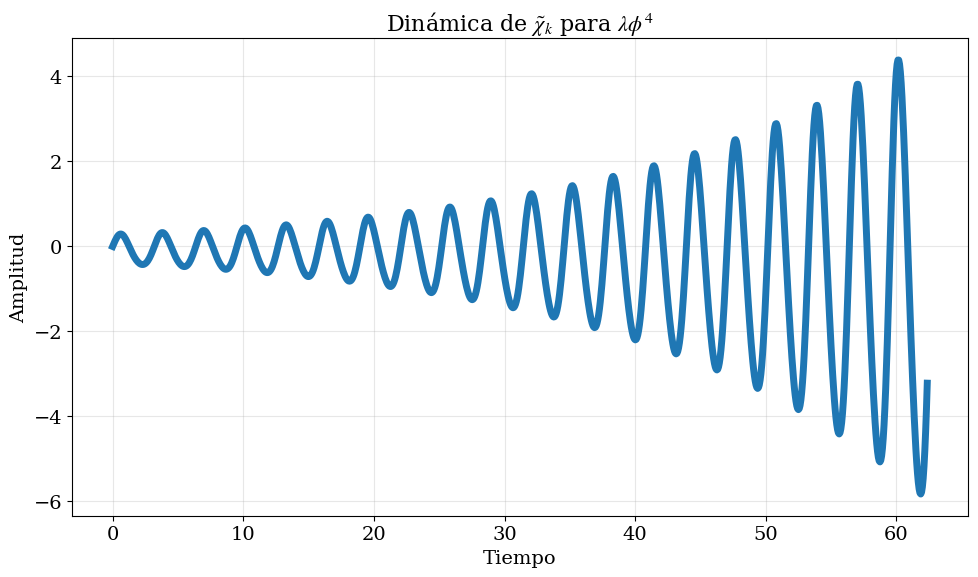

In [21]:
# Resolvamos la dinámica completa para un caso particular

q = 3.09
k = 1.48

# Condiciones iniciales
# Background
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)
# Perturbaciones
Omega_chi = k**2 + q**2 * phi0**2
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]

Tosc = oscilation_lphi4(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)
sol = solve_ivp(perturbation_lphi4, t_span, y0, t_eval=np.linspace(0, 10 * Tosc, 1000), method='RK45', rtol=1e-6, args=(k, q))


plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[2], label=r'$\chi_k(t)$', lw = 5)
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.title(r'Dinámica de $\tilde{\chi}_k$ para $\lambda \phi^4$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Número de partículas

El número de partículas del campo hijo estará dado por

$$n_\chi (k) = \frac{1}{2 \Omega_\chi} \left( \left| \frac{d \chi_k}{dT} \right|^2 + \Omega^2_\chi \left| \chi_k \right|^2 \right) - \frac{1}{2}$$

dónde

$$\Omega_\chi^2 (k, t) = \frac{k^2}{a^2} + g^2 \phi^2 (t)$$

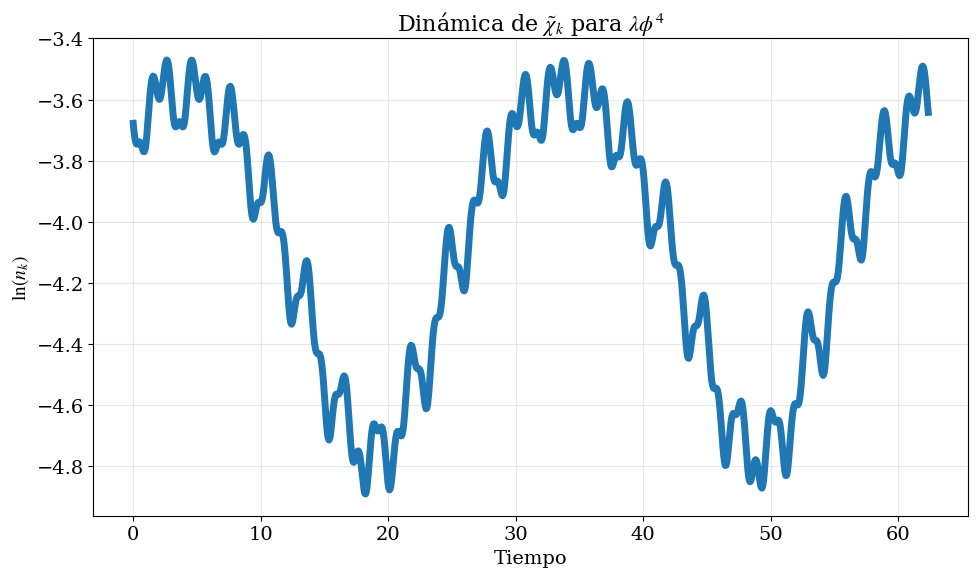

In [59]:
q = 4
k = 1.5

# Condiciones iniciales
# Background
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)
# Perturbaciones
Omega_chi = k**2 + q**2 * phi0**2
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]

Tosc = oscilation_lphi4(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)
sol = solve_ivp(perturbation_lphi4, t_span, y0, t_eval=np.linspace(0, 10 * Tosc, 1000), method='RK45', rtol=1e-6, args=(k, q))

omega_k = np.sqrt(k**2 + q * sol.y[0]**2)

nk = omega_k / 2 * ( np.abs(sol.y[3])**2 / omega_k**2 + np.abs(sol.y[2])**2 )

plt.figure(figsize=(10, 6))
plt.plot(sol.t, np.log(nk), lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\ln(n_k)$')
plt.title(r'Dinámica de $\tilde{\chi}_k$ para $\lambda \phi^4$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

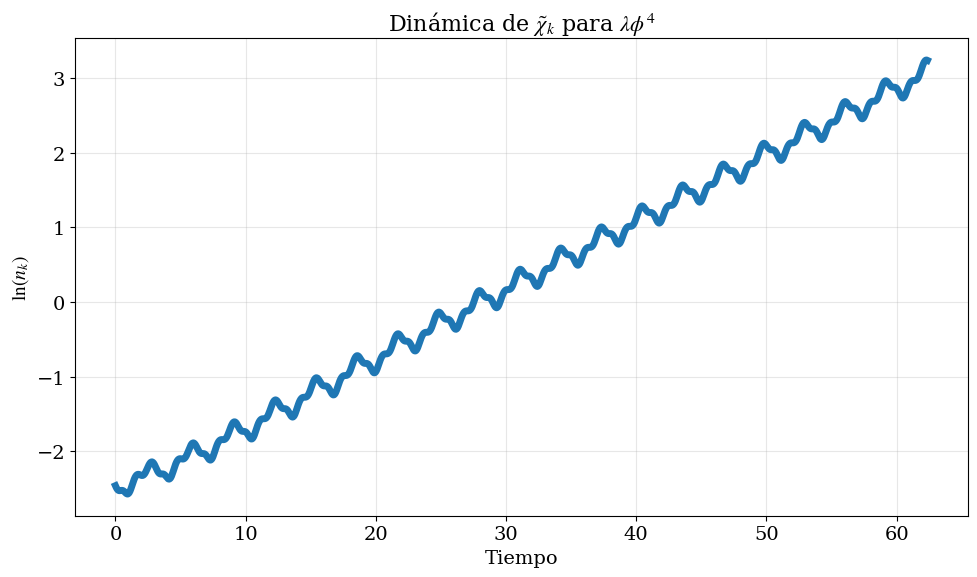

In [46]:
q = 3.09
k = 1.48

# Condiciones iniciales
# Background
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)
# Perturbaciones
Omega_chi = k**2 + q**2 * phi0**2
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]

Tosc = oscilation_lphi4(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)
sol = solve_ivp(perturbation_lphi4, t_span, y0, t_eval=np.linspace(0, 10 * Tosc, 1000), method='RK45', rtol=1e-6, args=(k, q))

omega_k = np.sqrt(k**2 + q * sol.y[0]**2)

nk = omega_k / 2 * ( np.abs(sol.y[3])**2 / omega_k**2 + np.abs(sol.y[2])**2 )

plt.figure(figsize=(10, 6))
plt.plot(sol.t, np.log(nk), lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\ln(n_k)$')
plt.title(r'Dinámica de $\tilde{\chi}_k$ para $\lambda \phi^4$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()